# Residency Day 1: Project Deliverable 1  
## Data Collection, Cleaning, and Exploration of NYC Airbnb Listings

**Student Name:** Sireesha Pudi, Vamsi Krishna Matta
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Project Phase:** Deliverable 1  
**Dataset:** New York City Airbnb Open Data, 2019  

## Project Objective

The purpose of this deliverable is to prepare and explore a real-world dataset before applying data-mining models in later project stages.

This notebook focuses on:

- Selecting and describing the dataset
- Loading and validating the data
- Inspecting its structure and data types
- Identifying missing values
- Checking duplicate records
- Correcting inconsistent text values
- Identifying invalid and noisy observations
- Preparing a reliable cleaned dataset for exploratory analysis

In [1]:
# Import libraries required for data manipulation and visualization

import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}"
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Libraries imported successfully.
Python version: 3.14.3
Pandas version: 3.0.5
Seaborn version: 0.13.2


## Dataset Selection and Justification

The New York City Airbnb 2019 dataset contains individual short-term rental listings from the five New York City borough groups.

The dataset is appropriate for this project because:

- It contains 48,895 records, exceeding the minimum requirement of 500 records.
- It includes 16 attributes with numerical, categorical, text, date, and geographic information.
- It contains genuine missing values that require thoughtful treatment.
- It includes extreme and noisy values in fields such as price and minimum nights.
- It supports meaningful exploratory visualizations and feature relationships.
- Nightly price can later be used as a regression target.
- Listing or price groups can support classification.
- Location, availability, price, and review features can support clustering.
- Discretized listing attributes can support association-rule mining.

The dataset therefore provides a suitable foundation for all later project deliverables.

In [2]:
# Load the confirmed NYC Airbnb dataset

airbnb_raw = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully.")
print("Number of rows:", airbnb_raw.shape[0])
print("Number of columns:", airbnb_raw.shape[1])

airbnb_raw.head()

Dataset loaded successfully.
Number of rows: 48895
Number of columns: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# Define the columns expected in the selected dataset

expected_columns = [
    "id",
    "name",
    "host_id",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

missing_columns = [
    column for column in expected_columns
    if column not in airbnb_raw.columns
]

unexpected_columns = [
    column for column in airbnb_raw.columns
    if column not in expected_columns
]

if missing_columns:
    raise ValueError(
        f"The dataset is missing expected columns: {missing_columns}"
    )

print("Dataset validation passed.")
print("All 16 expected columns are available.")
print("Unexpected columns:", unexpected_columns)

Dataset validation passed.
All 16 expected columns are available.
Unexpected columns: []


In [4]:
# Display random observations to inspect different listings

airbnb_raw.sample(
    n=8,
    random_state=42
)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64,-73.98,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
44383,34205267,"Spacious, sunny room in Queens/Brooklyn",913940,Giancarlo,Queens,Ridgewood,40.71,-73.91,Private room,30,21,0,NaN,NaN,1,73
15394,12342297,Private bedroom in high-ceiling 4BR apartment!,19953913,Alejandro,Manhattan,Hell's Kitchen,40.76,-73.99,Private room,120,2,17,2017-04-28,0.43,1,0
43230,33527778,Sonder | Stock Exchange | Stunning 3BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.71,-74.01,Entire home/apt,470,2,5,2019-06-02,1.88,327,272
16332,13136376,Spacious 2 Bedroom with Balcony,16110448,Gingie,Manhattan,East Harlem,40.80,-73.93,Entire home/apt,199,2,30,2019-06-03,0.80,1,30
5966,4365276,Entire 2BR APT (not a railroad),3081990,Amanda,Brooklyn,Williamsburg,40.71,-73.95,Entire home/apt,170,1,141,2019-06-22,3.05,1,28
29838,22968206,1br in spacious 2 br in the heart of Williamsburg,22748648,Hugo,Brooklyn,Williamsburg,40.71,-73.96,Private room,90,5,1,2018-02-21,0.06,1,0
41764,32472023,comfortable Place to live,209376540,Jing,Queens,College Point,40.77,-73.85,Entire home/apt,60,30,0,NaN,NaN,1,121


## Dataset Attributes

| Attribute | Description |
|---|---|
| id | Unique identifier assigned to each listing |
| name | Public title of the Airbnb listing |
| host_id | Unique identifier assigned to the host |
| host_name | Display name of the host |
| neighbourhood_group | New York City borough group |
| neighbourhood | Specific neighborhood containing the listing |
| latitude | Geographic latitude of the listing |
| longitude | Geographic longitude of the listing |
| room_type | Type of accommodation offered |
| price | Nightly listing price in U.S. dollars |
| minimum_nights | Minimum number of nights required for booking |
| number_of_reviews | Total number of reviews received |
| last_review | Date of the latest recorded review |
| reviews_per_month | Average monthly review activity |
| calculated_host_listings_count | Number of listings associated with the host |
| availability_365 | Number of days the listing is available annually |

In [5]:
# Display data types, non-null counts, and memory information

airbnb_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
# Summarize data type, completeness, and uniqueness for each attribute

structure_summary = pd.DataFrame({
    "Attribute": airbnb_raw.columns,
    "Data Type": airbnb_raw.dtypes.astype(str).values,
    "Non-Null Records": airbnb_raw.notna().sum().values,
    "Missing Records": airbnb_raw.isna().sum().values,
    "Unique Values": airbnb_raw.nunique(dropna=True).values
})

structure_summary

,Attribute,Data Type,Non-Null Records,Missing Records,Unique Values
0,id,int64,48895,0,48895
1,name,str,48879,16,47905
2,host_id,int64,48895,0,37457
3,host_name,str,48874,21,11452
4,neighbourhood_group,str,48895,0,5
5,neighbourhood,str,48895,0,221
6,latitude,float64,48895,0,19048
7,longitude,float64,48895,0,14718
8,room_type,str,48895,0,3
9,price,int64,48895,0,674


In [7]:
# Select meaningful numerical variables for descriptive analysis

numeric_features = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

descriptive_summary = (
    airbnb_raw[numeric_features]
    .describe()
    .transpose()
)

descriptive_summary["range"] = (
    descriptive_summary["max"]
    - descriptive_summary["min"]
)

descriptive_summary["missing_values"] = (
    airbnb_raw[numeric_features]
    .isna()
    .sum()
)

descriptive_summary

,count,mean,std,min,25%,50%,75%,max,range,missing_values
latitude,"48,895.00",40.73,0.05,40.50,40.69,40.72,40.76,40.91,0.41,0
longitude,"48,895.00",-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71,0.53,0
price,"48,895.00",152.72,240.15,0.00,69.00,106.00,175.00,"10,000.00","10,000.00",0
minimum_nights,"48,895.00",7.03,20.51,1.00,1.00,3.00,5.00,"1,250.00","1,249.00",0
number_of_reviews,"48,895.00",23.27,44.55,0.00,1.00,5.00,24.00,629.00,629.00,0
reviews_per_month,"38,843.00",1.37,1.68,0.01,0.19,0.72,2.02,58.50,58.49,10052
calculated_host_listings_count,"48,895.00",7.14,32.95,1.00,1.00,1.00,2.00,327.00,326.00,0
availability_365,"48,895.00",112.78,131.62,0.00,0.00,45.00,227.00,365.00,365.00,0


In [8]:
# Summarize the main categorical attributes

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

categorical_summary = (
    airbnb_raw[categorical_features]
    .describe()
    .transpose()
)

categorical_summary

,count,unique,top,freq
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409


In [9]:
# Calculate missing-value counts and percentages

missing_summary = pd.DataFrame({
    "Missing Count": airbnb_raw.isna().sum(),
    "Missing Percentage": (
        airbnb_raw.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        by="Missing Count",
        ascending=False
    )
)

missing_summary

,Missing Count,Missing Percentage
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


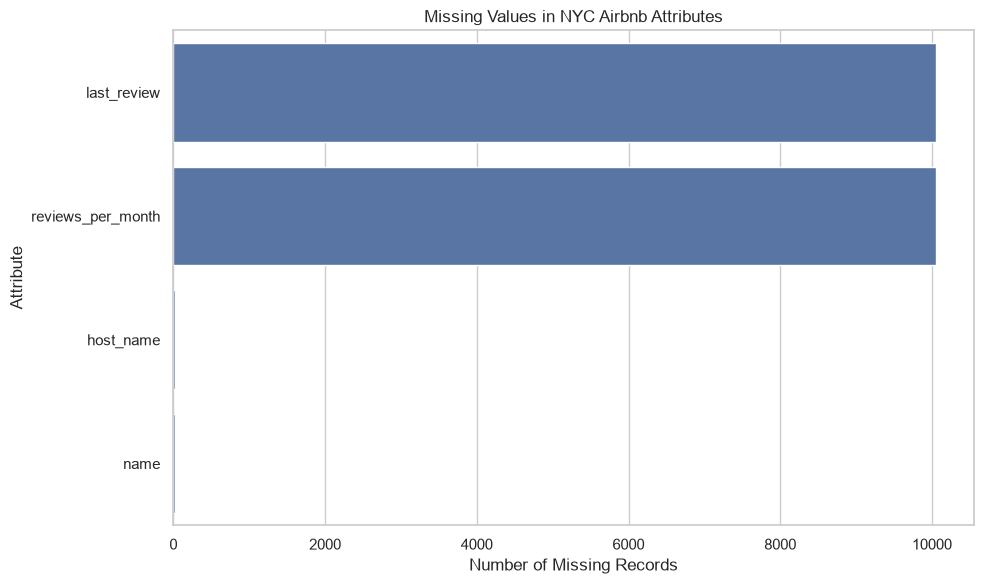

In [10]:
# Keep only attributes that actually contain missing values

missing_plot_data = (
    missing_summary
    .reset_index()
    .rename(columns={"index": "Attribute"})
)

missing_plot_data = missing_plot_data[
    missing_plot_data["Missing Count"] > 0
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_plot_data,
    x="Missing Count",
    y="Attribute"
)

plt.title("Missing Values in NYC Airbnb Attributes")
plt.xlabel("Number of Missing Records")
plt.ylabel("Attribute")

plt.tight_layout()
plt.show()

## Missing-Value Treatment Strategy

Missing values were handled according to the meaning of each attribute rather than applying one method to the entire dataset.

- Missing listing names were replaced with `Unnamed Listing`.
- Missing host names were replaced with `Unknown Host`.
- Missing `reviews_per_month` values were replaced with zero because listings without recorded reviews do not have measurable monthly review activity.
- Missing `last_review` values were preserved as missing dates because a listing may never have received a review.

This approach preserves valid listings while preventing text and review-rate fields from disrupting later analysis.

In [11]:
# Preserve the original dataset and create a separate cleaning copy

airbnb_clean = airbnb_raw.copy()

# Replace missing text labels with meaningful placeholders
airbnb_clean["name"] = (
    airbnb_clean["name"]
    .fillna("Unnamed Listing")
)

airbnb_clean["host_name"] = (
    airbnb_clean["host_name"]
    .fillna("Unknown Host")
)

# Replace missing review rates with zero
airbnb_clean["reviews_per_month"] = (
    airbnb_clean["reviews_per_month"]
    .fillna(0)
)

# Convert review dates to a proper datetime type
airbnb_clean["last_review"] = pd.to_datetime(
    airbnb_clean["last_review"],
    errors="coerce"
)

remaining_missing = pd.DataFrame({
    "Remaining Missing Values":
        airbnb_clean.isna().sum()
})

remaining_missing[
    remaining_missing["Remaining Missing Values"] > 0
]

,Remaining Missing Values
last_review,10052


In [12]:
# Compare missing values before and after treatment

missing_comparison = pd.DataFrame({
    "Original Missing": airbnb_raw.isna().sum(),
    "After Treatment": airbnb_clean.isna().sum(),
    "Values Addressed": (
        airbnb_raw.isna().sum()
        - airbnb_clean.isna().sum()
    )
})

missing_comparison[
    (missing_comparison["Original Missing"] > 0)
    | (missing_comparison["After Treatment"] > 0)
]

,Original Missing,After Treatment,Values Addressed
name,16,0,16
host_name,21,0,21
last_review,10052,10052,0
reviews_per_month,10052,0,10052


In [13]:
# Check several possible forms of duplication

exact_duplicate_count = (
    airbnb_clean
    .duplicated()
    .sum()
)

duplicate_id_count = (
    airbnb_clean["id"]
    .duplicated()
    .sum()
)

repeated_profile_count = (
    airbnb_clean
    .duplicated(
        subset=[
            "host_id",
            "name",
            "latitude",
            "longitude",
            "room_type"
        ]
    )
    .sum()
)

duplicate_summary = pd.DataFrame({
    "Duplicate Test": [
        "Exact duplicate rows",
        "Duplicate listing IDs",
        "Repeated listing profiles"
    ],
    "Count": [
        exact_duplicate_count,
        duplicate_id_count,
        repeated_profile_count
    ]
})

duplicate_summary

,Duplicate Test,Count
0,Exact duplicate rows,0
1,Duplicate listing IDs,0
2,Repeated listing profiles,0


In [14]:
# Record the number of observations before duplicate processing

rows_before_duplicate_cleaning = len(airbnb_clean)

# Remove exact duplicates and repeated listing IDs
airbnb_clean = (
    airbnb_clean
    .drop_duplicates()
    .drop_duplicates(
        subset=["id"],
        keep="first"
    )
    .reset_index(drop=True)
)

rows_after_duplicate_cleaning = len(airbnb_clean)

print(
    "Rows before duplicate processing:",
    rows_before_duplicate_cleaning
)

print(
    "Rows after duplicate processing:",
    rows_after_duplicate_cleaning
)

print(
    "Rows removed:",
    rows_before_duplicate_cleaning
    - rows_after_duplicate_cleaning
)

Rows before duplicate processing: 48895
Rows after duplicate processing: 48895
Rows removed: 0


## Duplicate-Record Decision

The dataset was evaluated for:

- Completely identical rows
- Repeated listing identifiers
- Repeated listing profiles based on host, title, coordinates, and room type

Exact duplicates and repeated listing IDs were removed because they could cause listings to be counted more than once.

Repeated listing profiles were inspected but were not automatically deleted because one host may legitimately operate similar units at the same location.

In [15]:
# Review the distinct borough and room-type values

borough_values = sorted(
    airbnb_clean["neighbourhood_group"]
    .dropna()
    .unique()
)

room_type_values = sorted(
    airbnb_clean["room_type"]
    .dropna()
    .unique()
)

print("Neighbourhood groups:")
print(borough_values)

print("\nRoom types:")
print(room_type_values)

print(
    "\nNumber of unique neighborhoods:",
    airbnb_clean["neighbourhood"].nunique()
)

Neighbourhood groups:
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

Room types:
['Entire home/apt', 'Private room', 'Shared room']

Number of unique neighborhoods: 221


In [16]:
# Remove leading, trailing, and repeated internal whitespace

text_features = [
    "name",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for column in text_features:
    airbnb_clean[column] = (
        airbnb_clean[column]
        .astype(str)
        .str.strip()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

print("Text attributes standardized successfully.")

airbnb_clean[
    [
        "name",
        "host_name",
        "neighbourhood_group",
        "neighbourhood",
        "room_type"
    ]
].head(10)

Text attributes standardized successfully.


,name,host_name,neighbourhood_group,neighbourhood,room_type
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,Entire home/apt
6,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,Private room
7,Large Furnished Room Near B'way,Shunichi,Manhattan,Hell's Kitchen,Private room
8,Cozy Clean Guest Room - Family Apt,MaryEllen,Manhattan,Upper West Side,Private room
9,Cute & Cozy Lower East Side 1 bdrm,Ben,Manhattan,Chinatown,Entire home/apt


In [17]:
# Identify invalid values using logical business rules

data_quality_summary = pd.DataFrame({
    "Condition": [
        "Price equal to or below zero",
        "Minimum nights below one",
        "Negative review count",
        "Negative reviews per month",
        "Availability below zero",
        "Availability above 365",
        "Latitude outside valid range",
        "Longitude outside valid range"
    ],
    "Count": [
        (airbnb_clean["price"] <= 0).sum(),
        (airbnb_clean["minimum_nights"] < 1).sum(),
        (airbnb_clean["number_of_reviews"] < 0).sum(),
        (airbnb_clean["reviews_per_month"] < 0).sum(),
        (airbnb_clean["availability_365"] < 0).sum(),
        (airbnb_clean["availability_365"] > 365).sum(),
        (
            ~airbnb_clean["latitude"]
            .between(-90, 90)
        ).sum(),
        (
            ~airbnb_clean["longitude"]
            .between(-180, 180)
        ).sum()
    ]
})

data_quality_summary

,Condition,Count
0,Price equal to or below zero,11
1,Minimum nights below one,0
2,Negative review count,0
3,Negative reviews per month,0
4,Availability below zero,0
5,Availability above 365,0
6,Latitude outside valid range,0
7,Longitude outside valid range,0


In [18]:
# Preserve counts before applying logical validation rules

rows_before_validation = len(airbnb_clean)

airbnb_clean = airbnb_clean[
    (airbnb_clean["price"] > 0)
    & (airbnb_clean["minimum_nights"] >= 1)
    & (airbnb_clean["number_of_reviews"] >= 0)
    & (airbnb_clean["reviews_per_month"] >= 0)
    & (airbnb_clean["availability_365"].between(0, 365))
    & (airbnb_clean["latitude"].between(-90, 90))
    & (airbnb_clean["longitude"].between(-180, 180))
].copy()

airbnb_clean.reset_index(
    drop=True,
    inplace=True
)

rows_after_validation = len(airbnb_clean)

print("Rows before validation:", rows_before_validation)
print("Rows after validation:", rows_after_validation)
print(
    "Invalid records removed:",
    rows_before_validation - rows_after_validation
)

Rows before validation: 48895
Rows after validation: 48884
Invalid records removed: 11


In [19]:
# Summarize the status of the dataset after initial cleaning

part1_summary = pd.DataFrame({
    "Measurement": [
        "Original rows",
        "Current rows",
        "Original columns",
        "Current columns",
        "Original total missing values",
        "Current total missing values",
        "Exact duplicates remaining",
        "Invalid prices remaining"
    ],
    "Value": [
        airbnb_raw.shape[0],
        airbnb_clean.shape[0],
        airbnb_raw.shape[1],
        airbnb_clean.shape[1],
        int(airbnb_raw.isna().sum().sum()),
        int(airbnb_clean.isna().sum().sum()),
        int(airbnb_clean.duplicated().sum()),
        int((airbnb_clean["price"] <= 0).sum())
    ]
})

part1_summary

,Measurement,Value
0,Original rows,48895
1,Current rows,48884
2,Original columns,16
3,Current columns,16
4,Original total missing values,20141
5,Current total missing values,10051
6,Exact duplicates remaining,0
7,Invalid prices remaining,0


The dataset was successfully loaded and validated against the expected Airbnb schema.

The initial cleaning process included:

- Inspecting 48,895 records and 16 original attributes
- Reviewing numerical and categorical summaries
- Identifying genuine missing values
- Replacing missing listing and host names
- Replacing missing monthly review rates with zero
- Converting review dates into datetime format
- Preserving unavailable review dates when no review history existed
- Checking exact, ID-based, and profile-based duplicates
- Standardizing text spacing
- Inspecting borough and room-type consistency
- Identifying invalid prices and other logically impossible values
- Removing records that violated required business rules

The cleaned dataset is now ready for outlier detection, feature engineering, and exploratory visualization in Part 2.

In [20]:
# Examine skewness and central tendency before treating outliers

eda_numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

distribution_summary = pd.DataFrame({
    "Mean": airbnb_clean[eda_numeric_columns].mean(),
    "Median": airbnb_clean[eda_numeric_columns].median(),
    "Standard Deviation": airbnb_clean[eda_numeric_columns].std(),
    "Skewness": airbnb_clean[eda_numeric_columns].skew(),
    "Minimum": airbnb_clean[eda_numeric_columns].min(),
    "Maximum": airbnb_clean[eda_numeric_columns].max()
}).round(2)

distribution_summary

,Mean,Median,Standard Deviation,Skewness,Minimum,Maximum
price,152.76,106.00,240.17,19.12,10.00,"10,000.00"
minimum_nights,7.03,3.00,20.51,21.83,1.00,"1,250.00"
number_of_reviews,23.27,5.00,44.55,3.69,0.00,629.00
reviews_per_month,1.09,0.37,1.60,3.30,0.00,58.50
calculated_host_listings_count,7.14,1.00,32.96,7.93,1.00,327.00
availability_365,112.78,45.00,131.63,0.76,0.00,365.00


## Distribution and Skewness Review

The mean and median help identify asymmetrical distributions. When the mean is much larger than the median, a variable is usually positively skewed because a small number of unusually high observations pull the mean upward.

The skewness values help determine which numerical features require closer outlier inspection before future regression, classification, and clustering tasks.

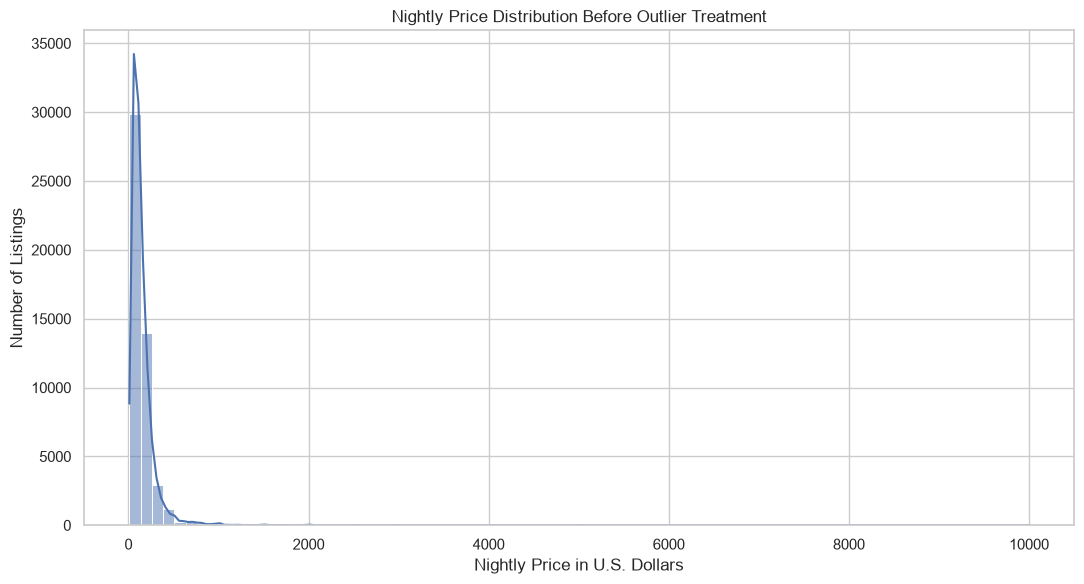

In [21]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=airbnb_clean,
    x="price",
    bins=80,
    kde=True
)

plt.title("Nightly Price Distribution Before Outlier Treatment")
plt.xlabel("Nightly Price in U.S. Dollars")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

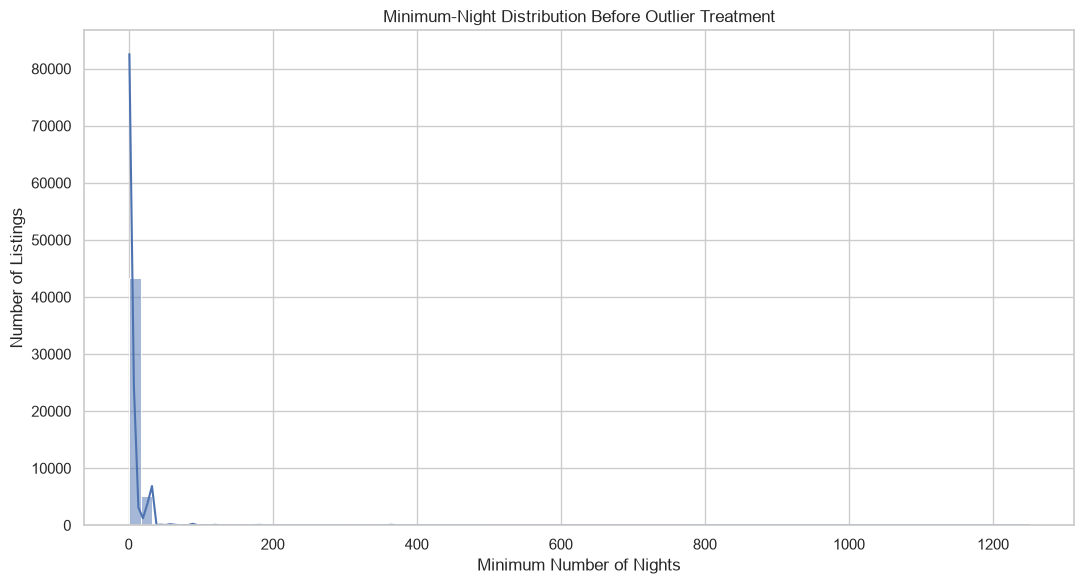

In [22]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=airbnb_clean,
    x="minimum_nights",
    bins=80,
    kde=True
)

plt.title("Minimum-Night Distribution Before Outlier Treatment")
plt.xlabel("Minimum Number of Nights")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

In [23]:
# Detect potential outliers using the interquartile-range method

outlier_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

outlier_records = []

for column in outlier_columns:
    q1 = airbnb_clean[column].quantile(0.25)
    q3 = airbnb_clean[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (airbnb_clean[column] < lower_bound)
        | (airbnb_clean[column] > upper_bound)
    )

    outlier_count = int(outlier_mask.sum())

    outlier_records.append({
        "Attribute": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count,
        "Outlier Percentage": (
            outlier_count / len(airbnb_clean) * 100
        )
    })

outlier_summary = pd.DataFrame(outlier_records)

outlier_summary.round(2)

,Attribute,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Outlier Percentage
0,price,69.00,175.00,106.00,-90.00,334.00,2972,6.08
1,minimum_nights,1.00,5.00,4.00,-5.00,11.00,6605,13.51
2,number_of_reviews,1.00,24.00,23.00,-33.50,58.50,6018,12.31
3,reviews_per_month,0.04,1.58,1.54,-2.27,3.89,3309,6.77
4,calculated_host_listings_count,1.00,2.00,1.00,-0.50,3.50,7073,14.47
5,availability_365,0.00,227.00,227.00,-340.50,567.50,0,0.00


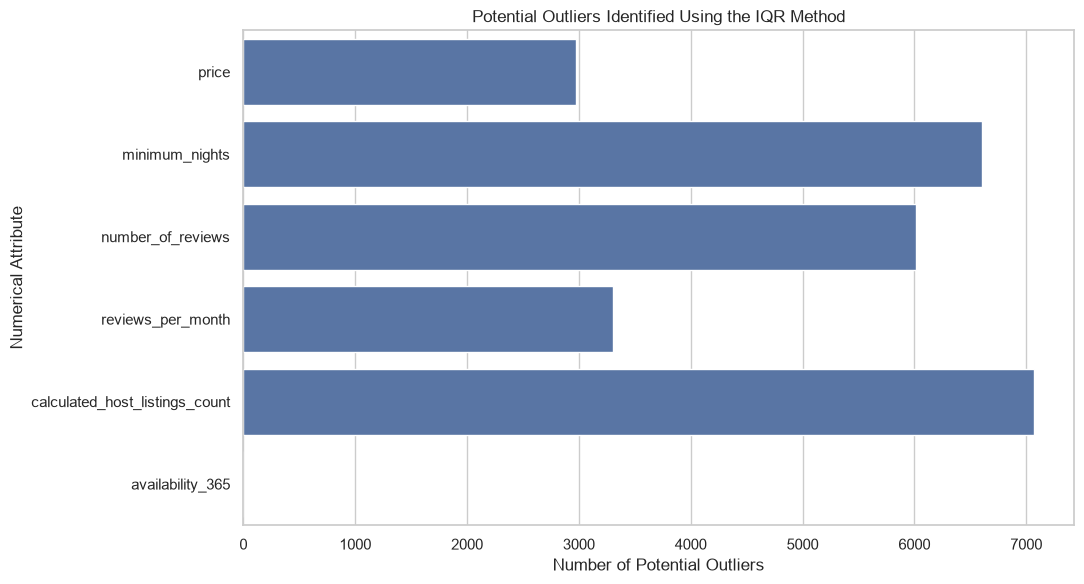

In [24]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=outlier_summary,
    x="Potential Outliers",
    y="Attribute"
)

plt.title("Potential Outliers Identified Using the IQR Method")
plt.xlabel("Number of Potential Outliers")
plt.ylabel("Numerical Attribute")

plt.tight_layout()
plt.show()

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn are ready.")

Matplotlib and Seaborn are ready.


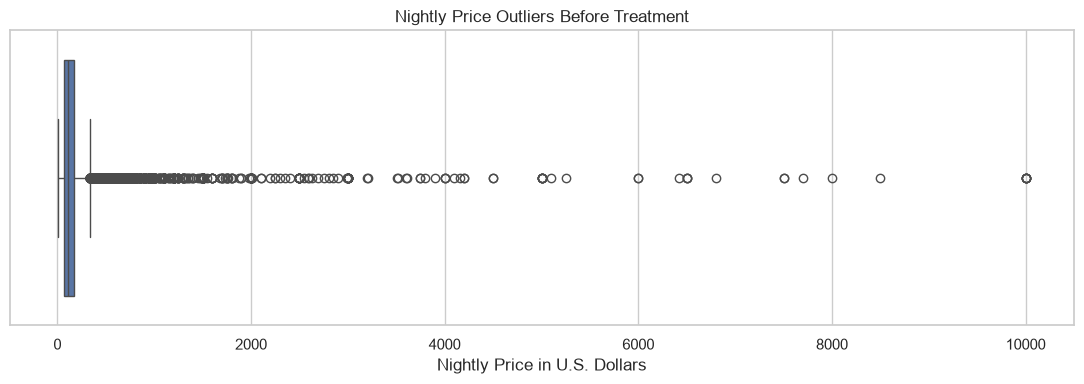

In [27]:
plt.figure(figsize=(11, 4))

sns.boxplot(
    data=airbnb_clean,
    x="price"
)

plt.title("Nightly Price Outliers Before Treatment")
plt.xlabel("Nightly Price in U.S. Dollars")

plt.tight_layout()
plt.show()

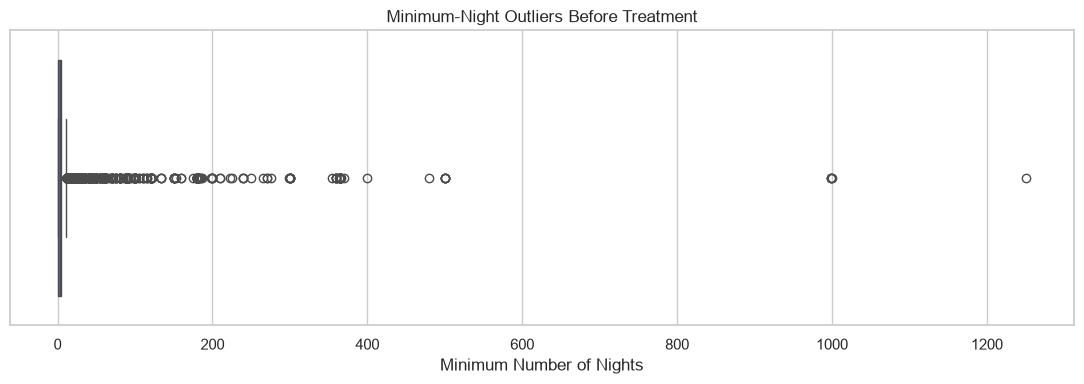

In [28]:
plt.figure(figsize=(11, 4))

sns.boxplot(
    data=airbnb_clean,
    x="minimum_nights"
)

plt.title("Minimum-Night Outliers Before Treatment")
plt.xlabel("Minimum Number of Nights")

plt.tight_layout()
plt.show()

## Outlier-Treatment Decision

The IQR analysis identifies many observations outside the conventional lower and upper boundaries. However, not every statistical outlier is an error.

For example:

- A high-priced listing may represent a luxury property.
- A large minimum-night requirement may represent a long-term rental.
- A host may legitimately manage many listings.
- A highly reviewed listing may simply be popular.

Removing every outlier would eliminate many valid listings. Therefore, percentile capping is used for selected numerical variables. Values below the first percentile are replaced by the first-percentile value, while values above the ninety-ninth percentile are replaced by the ninety-ninth-percentile value.

Availability is not capped because its valid range is already restricted to 0–365 days.

In [29]:
# Preserve the validated dataset before modifying extreme values

airbnb_before_capping = airbnb_clean.copy()

print("Copy created before outlier treatment.")
print("Rows:", airbnb_before_capping.shape[0])
print("Columns:", airbnb_before_capping.shape[1])

Copy created before outlier treatment.
Rows: 48884
Columns: 16


In [30]:
# Apply percentile capping to selected highly skewed variables

capping_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

capping_records = []

for column in capping_columns:
    lower_cap = airbnb_clean[column].quantile(0.01)
    upper_cap = airbnb_clean[column].quantile(0.99)

    values_below = int(
        (airbnb_clean[column] < lower_cap).sum()
    )

    values_above = int(
        (airbnb_clean[column] > upper_cap).sum()
    )

    airbnb_clean[column] = airbnb_clean[column].clip(
        lower=lower_cap,
        upper=upper_cap
    )

    capping_records.append({
        "Attribute": column,
        "Lower Cap": lower_cap,
        "Upper Cap": upper_cap,
        "Values Below Lower Cap": values_below,
        "Values Above Upper Cap": values_above
    })

capping_summary = pd.DataFrame(capping_records)

capping_summary.round(2)

,Attribute,Lower Cap,Upper Cap,Values Below Lower Cap,Values Above Upper Cap
0,price,30.00,799.00,393,474
1,minimum_nights,1.00,45.00,0,469
2,number_of_reviews,0.00,214.00,0,480
3,reviews_per_month,0.00,6.80,0,486
4,calculated_host_listings_count,1.00,232.00,0,327


In [31]:
before_after_outliers = pd.DataFrame({
    "Attribute": capping_columns,
    "Original Minimum": [
        airbnb_before_capping[column].min()
        for column in capping_columns
    ],
    "Capped Minimum": [
        airbnb_clean[column].min()
        for column in capping_columns
    ],
    "Original Maximum": [
        airbnb_before_capping[column].max()
        for column in capping_columns
    ],
    "Capped Maximum": [
        airbnb_clean[column].max()
        for column in capping_columns
    ]
})

before_after_outliers.round(2)

,Attribute,Original Minimum,Capped Minimum,Original Maximum,Capped Maximum
0,price,10.00,30.00,"10,000.00",799.00
1,minimum_nights,1.00,1.00,"1,250.00",45.00
2,number_of_reviews,0.00,0.00,629.00,214.00
3,reviews_per_month,0.00,0.00,58.50,6.80
4,calculated_host_listings_count,1.00,1.00,327.00,232.00


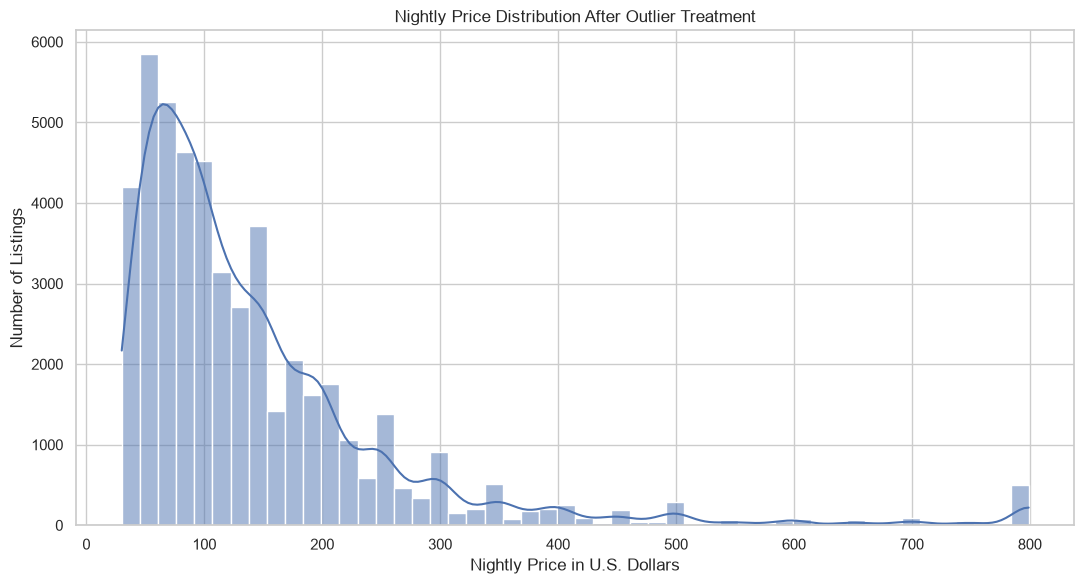

In [32]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=airbnb_clean,
    x="price",
    bins=50,
    kde=True
)

plt.title("Nightly Price Distribution After Outlier Treatment")
plt.xlabel("Nightly Price in U.S. Dollars")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

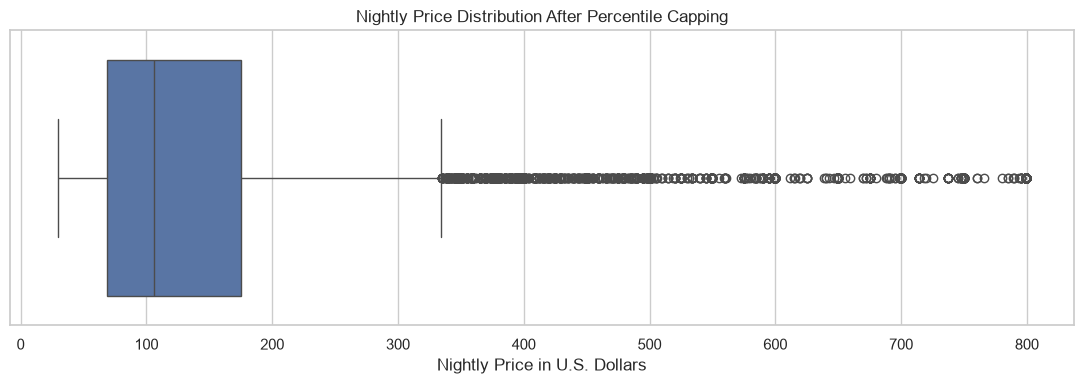

In [33]:
plt.figure(figsize=(11, 4))

sns.boxplot(
    data=airbnb_clean,
    x="price"
)

plt.title("Nightly Price Distribution After Percentile Capping")
plt.xlabel("Nightly Price in U.S. Dollars")

plt.tight_layout()
plt.show()

In [34]:
# Create an interpretable price category for later analysis

airbnb_clean["price_category"] = pd.cut(
    airbnb_clean["price"],
    bins=[0, 100, 200, 350, np.inf],
    labels=[
        "Budget",
        "Moderate",
        "Premium",
        "Luxury"
    ],
    include_lowest=True
)

price_category_summary = (
    airbnb_clean["price_category"]
    .value_counts()
    .sort_index()
    .rename_axis("Price Category")
    .reset_index(name="Listing Count")
)

price_category_summary

,Price Category,Listing Count
0,Budget,23917
1,Moderate,16583
2,Premium,5928
3,Luxury,2456


In [35]:
# Distinguish listings with and without review activity

airbnb_clean["review_status"] = np.where(
    airbnb_clean["number_of_reviews"] > 0,
    "Reviewed",
    "Not Reviewed"
)

review_status_summary = (
    airbnb_clean["review_status"]
    .value_counts()
    .rename_axis("Review Status")
    .reset_index(name="Listing Count")
)

review_status_summary

,Review Status,Listing Count
0,Reviewed,38833
1,Not Reviewed,10051


In [36]:
# Group annual availability into meaningful levels

airbnb_clean["availability_level"] = pd.cut(
    airbnb_clean["availability_365"],
    bins=[-1, 90, 180, 270, 365],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

availability_summary = (
    airbnb_clean["availability_level"]
    .value_counts()
    .sort_index()
    .rename_axis("Availability Level")
    .reset_index(name="Listing Count")
)

availability_summary

,Availability Level,Listing Count
0,Low,29241
1,Moderate,5282
2,High,4511
3,Very High,9850


In [37]:
# Categorize hosts according to the number of listings they manage

airbnb_clean["host_activity"] = pd.cut(
    airbnb_clean["calculated_host_listings_count"],
    bins=[0, 1, 5, 20, np.inf],
    labels=[
        "Single Listing Host",
        "Small Portfolio Host",
        "Medium Portfolio Host",
        "Large Portfolio Host"
    ],
    include_lowest=True
)

host_activity_summary = (
    airbnb_clean["host_activity"]
    .value_counts()
    .sort_index()
    .rename_axis("Host Activity")
    .reset_index(name="Listing Count")
)

host_activity_summary

,Host Activity,Listing Count
0,Single Listing Host,32301
1,Small Portfolio Host,11792
2,Medium Portfolio Host,2586
3,Large Portfolio Host,2205


In [38]:
airbnb_clean[
    [
        "price",
        "price_category",
        "number_of_reviews",
        "review_status",
        "availability_365",
        "availability_level",
        "calculated_host_listings_count",
        "host_activity"
    ]
].head(12)

,price,price_category,number_of_reviews,review_status,availability_365,availability_level,calculated_host_listings_count,host_activity
0,149,Moderate,9,Reviewed,365,Very High,6,Medium Portfolio Host
1,225,Premium,45,Reviewed,355,Very High,2,Small Portfolio Host
2,150,Moderate,0,Not Reviewed,365,Very High,1,Single Listing Host
3,89,Budget,214,Reviewed,194,High,1,Single Listing Host
4,80,Budget,9,Reviewed,0,Low,1,Single Listing Host
5,200,Moderate,74,Reviewed,129,Moderate,1,Single Listing Host
6,60,Budget,49,Reviewed,0,Low,1,Single Listing Host
7,79,Budget,214,Reviewed,220,High,1,Single Listing Host
8,79,Budget,118,Reviewed,0,Low,1,Single Listing Host
9,150,Moderate,160,Reviewed,188,High,4,Small Portfolio Host


## Feature-Engineering Rationale

Four categorical features were created:

- `price_category` divides listings into Budget, Moderate, Premium, and Luxury groups.
- `review_status` identifies whether a listing has received any reviews.
- `availability_level` groups annual availability into four ranges.
- `host_activity` distinguishes individual hosts from hosts managing larger portfolios.

These features make the dataset easier to interpret and can support classification, clustering, and association-rule mining in later deliverables.

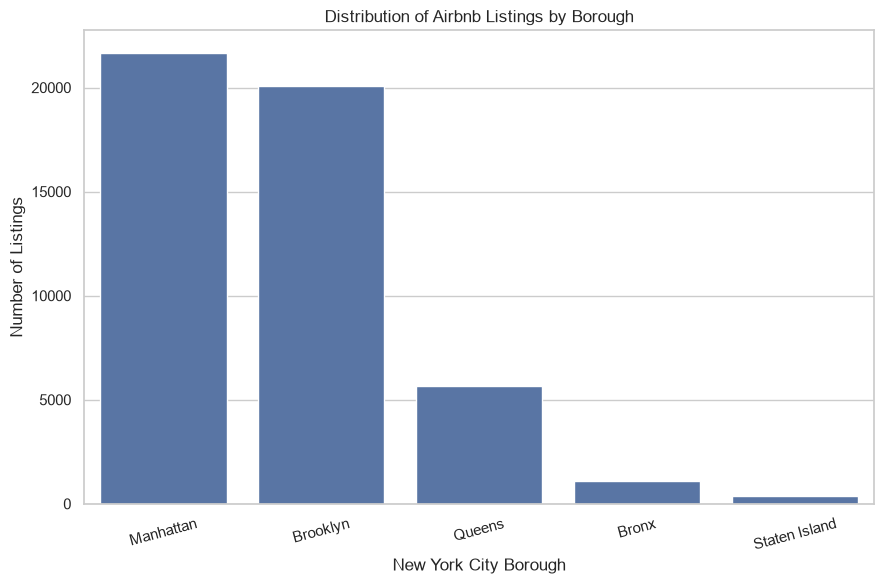

In [39]:
borough_summary = (
    airbnb_clean["neighbourhood_group"]
    .value_counts()
    .rename_axis("Borough")
    .reset_index(name="Listing Count")
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=borough_summary,
    x="Borough",
    y="Listing Count"
)

plt.title("Distribution of Airbnb Listings by Borough")
plt.xlabel("New York City Borough")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Borough Distribution Insight

The borough chart shows how Airbnb supply is distributed across New York City. Boroughs with larger listing counts represent the primary areas of platform activity.

This feature is likely to be important in future price prediction because housing markets, tourism demand, accessibility, and neighborhood characteristics vary substantially across boroughs.

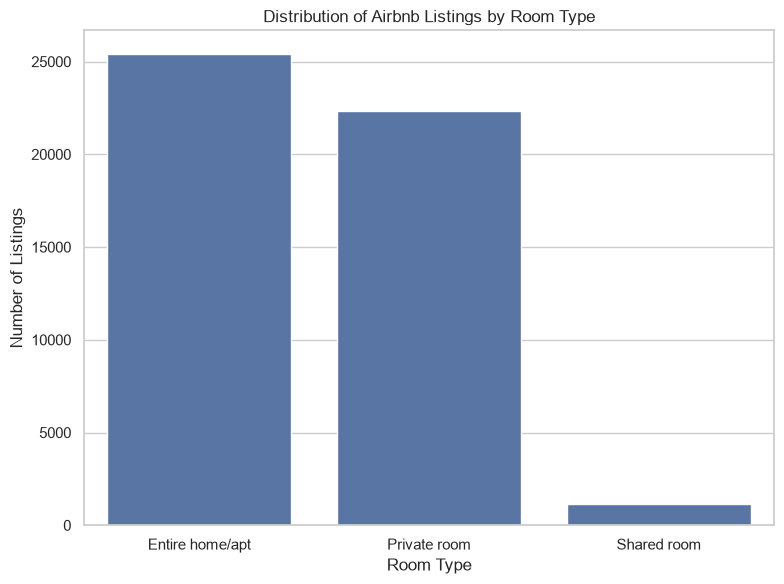

In [40]:
room_type_summary = (
    airbnb_clean["room_type"]
    .value_counts()
    .rename_axis("Room Type")
    .reset_index(name="Listing Count")
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=room_type_summary,
    x="Room Type",
    y="Listing Count"
)

plt.title("Distribution of Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

### Room Type Insight

The listing inventory is not evenly distributed across room types. Entire homes or apartments and private rooms account for most listings, while shared rooms are less common.

Room type is expected to have a major relationship with nightly price because an entire property usually offers more privacy and space than a private or shared room.

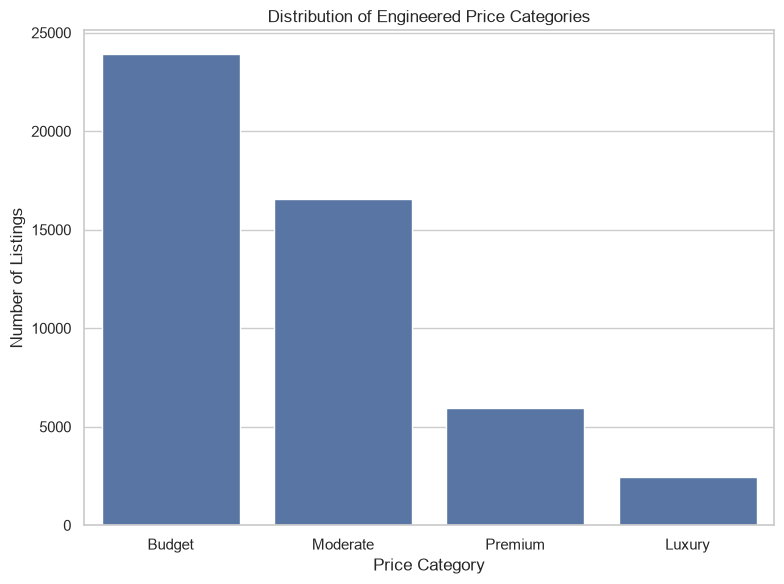

In [41]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=price_category_summary,
    x="Price Category",
    y="Listing Count"
)

plt.title("Distribution of Engineered Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

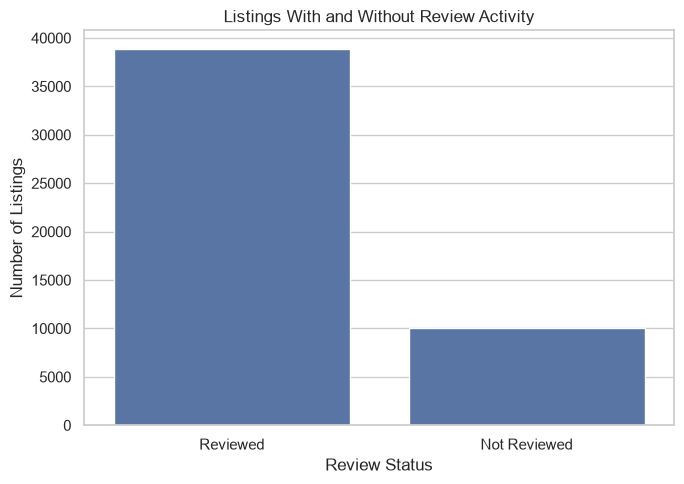

In [42]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=review_status_summary,
    x="Review Status",
    y="Listing Count"
)

plt.title("Listings With and Without Review Activity")
plt.xlabel("Review Status")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

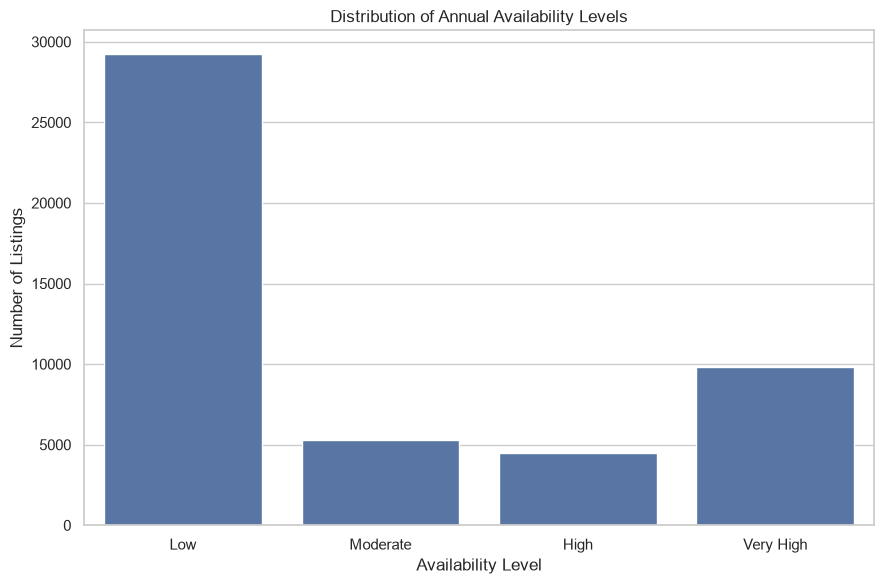

In [43]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=availability_summary,
    x="Availability Level",
    y="Listing Count"
)

plt.title("Distribution of Annual Availability Levels")
plt.xlabel("Availability Level")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

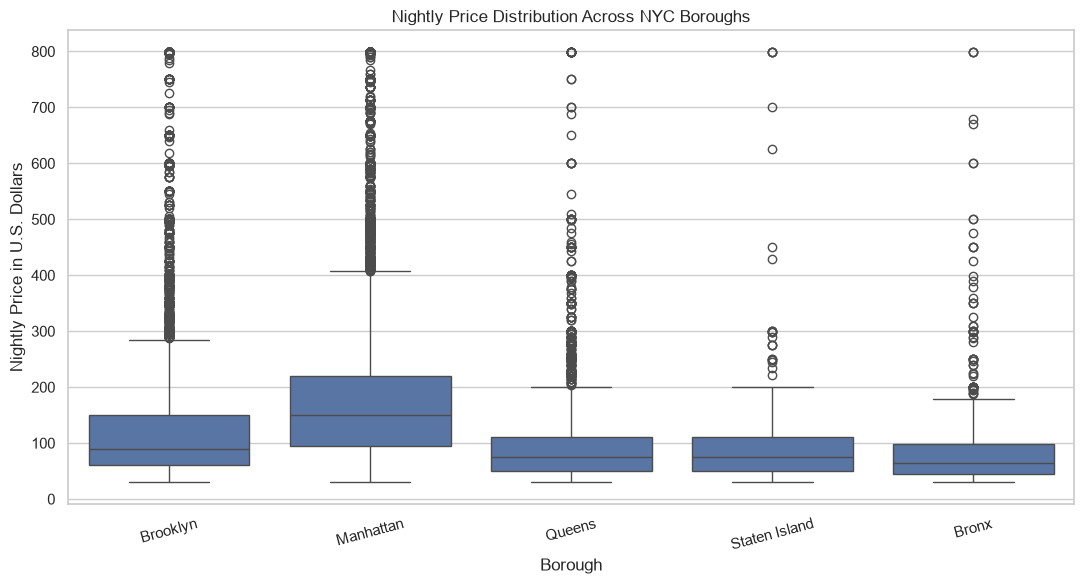

In [44]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=airbnb_clean,
    x="neighbourhood_group",
    y="price"
)

plt.title("Nightly Price Distribution Across NYC Boroughs")
plt.xlabel("Borough")
plt.ylabel("Nightly Price in U.S. Dollars")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Borough and Price Insight

The boxplot compares the typical nightly price and price variation across boroughs. Differences in medians and interquartile ranges suggest that geographic location contributes to listing price.

Borough should therefore be retained as an explanatory feature in future regression and classification models.

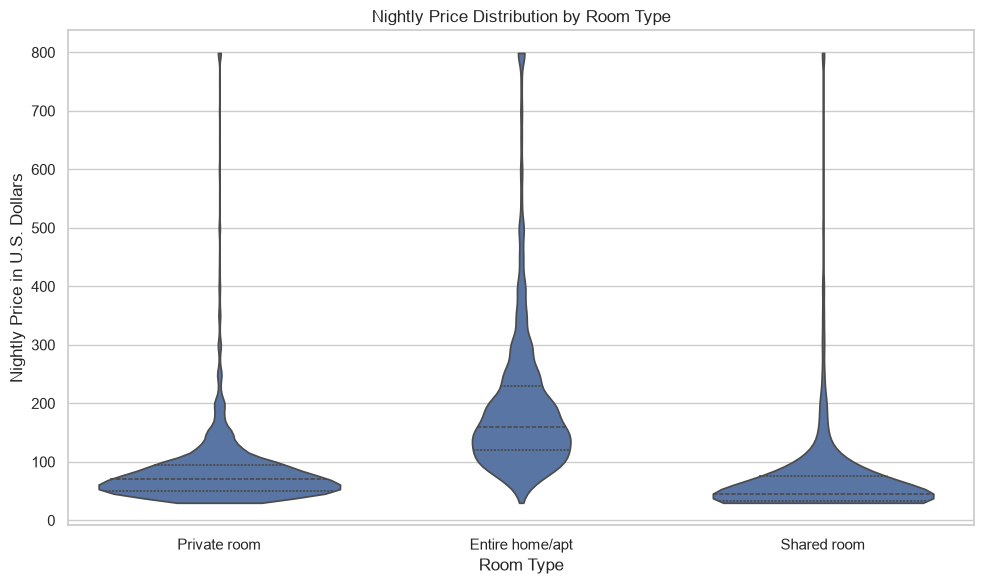

In [45]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=airbnb_clean,
    x="room_type",
    y="price",
    inner="quartile",
    cut=0
)

plt.title("Nightly Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price in U.S. Dollars")

plt.tight_layout()
plt.show()

### Room Type and Price Insight

The violin plot displays both price concentration and distribution shape for each room type. Differences across categories indicate that room type is an important predictor of nightly price.

The relationship may also help explain customer-market segments, such as budget travelers choosing shared rooms and larger groups selecting entire homes.

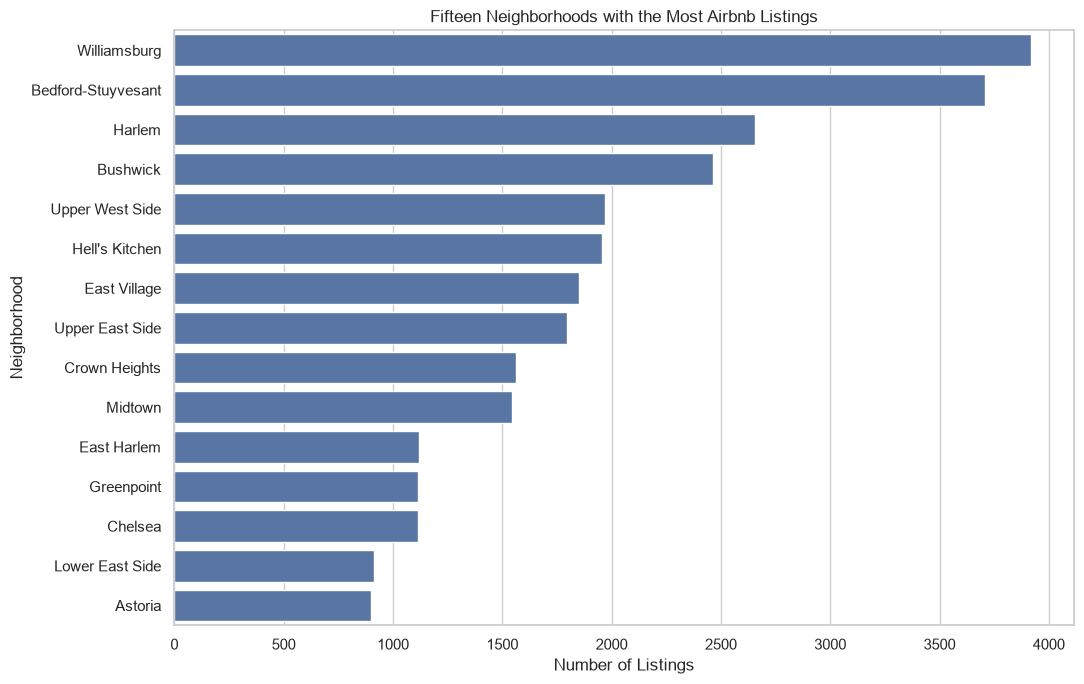

In [46]:
top_neighbourhoods = (
    airbnb_clean["neighbourhood"]
    .value_counts()
    .head(15)
    .rename_axis("Neighborhood")
    .reset_index(name="Listing Count")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_neighbourhoods,
    x="Listing Count",
    y="Neighborhood"
)

plt.title("Fifteen Neighborhoods with the Most Airbnb Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")

plt.tight_layout()
plt.show()

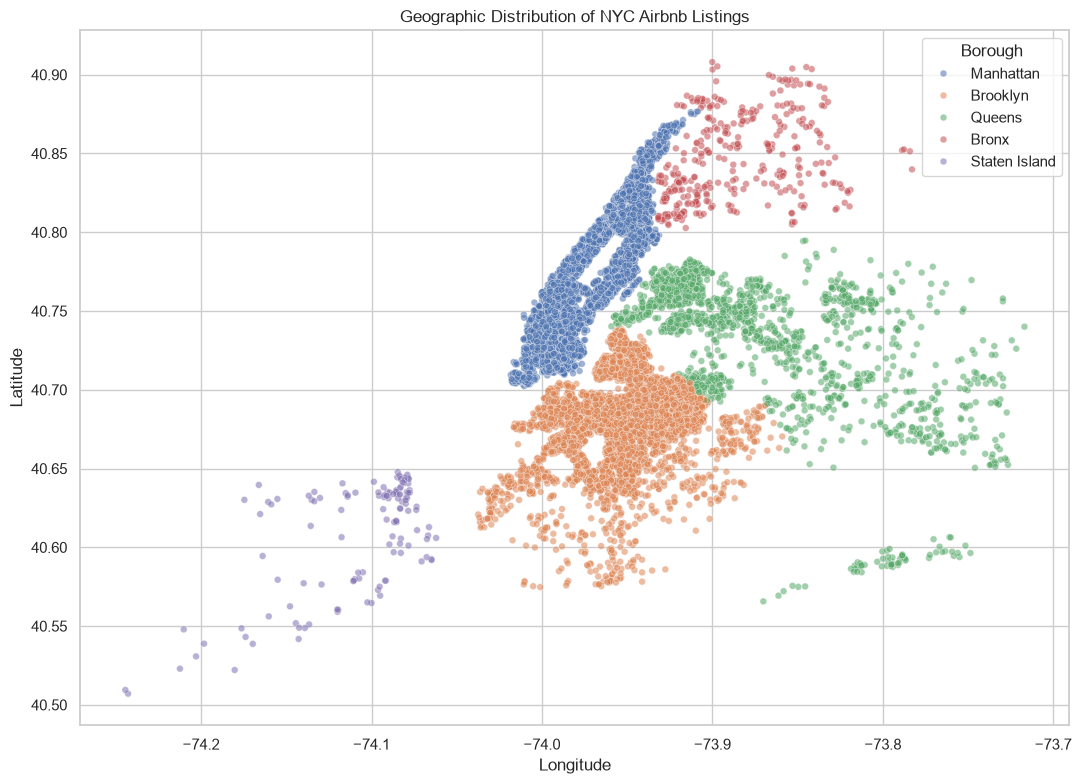

In [47]:
# Use a reproducible sample to keep the visualization clear

geographic_sample = airbnb_clean.sample(
    n=min(15000, len(airbnb_clean)),
    random_state=42
)

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=geographic_sample,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    alpha=0.55,
    s=24
)

plt.title("Geographic Distribution of NYC Airbnb Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Borough")

plt.tight_layout()
plt.show()

### Geographic Distribution Insight

The latitude-longitude scatter plot forms recognizable geographic clusters corresponding to New York City boroughs.

The listing concentration is not geographically uniform. This suggests that location-based attributes, including latitude, longitude, borough, and neighborhood, should be considered in future modeling.

In [48]:
borough_room_price = (
    airbnb_clean
    .groupby(
        [
            "neighbourhood_group",
            "room_type"
        ],
        observed=True
    )["price"]
    .mean()
    .round(2)
    .reset_index(name="Average Price")
)

borough_room_price

,neighbourhood_group,room_type,Average Price
0,Bronx,Entire home/apt,126.98
1,Bronx,Private room,64.46
2,Bronx,Shared room,61.68
3,Brooklyn,Entire home/apt,170.59
4,Brooklyn,Private room,73.96
5,Brooklyn,Shared room,52.06
6,Manhattan,Entire home/apt,229.89
7,Manhattan,Private room,111.08
8,Manhattan,Shared room,88.70
9,Queens,Entire home/apt,143.68


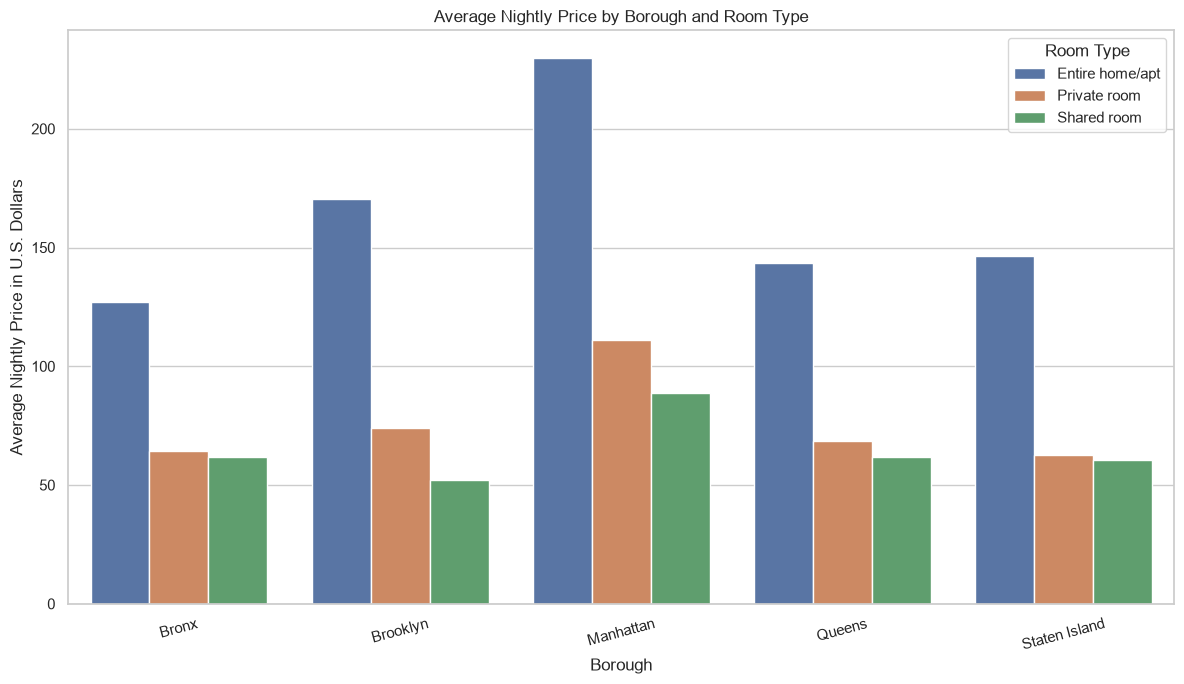

In [49]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=borough_room_price,
    x="neighbourhood_group",
    y="Average Price",
    hue="room_type"
)

plt.title("Average Nightly Price by Borough and Room Type")
plt.xlabel("Borough")
plt.ylabel("Average Nightly Price in U.S. Dollars")
plt.xticks(rotation=15)
plt.legend(title="Room Type")

plt.tight_layout()
plt.show()

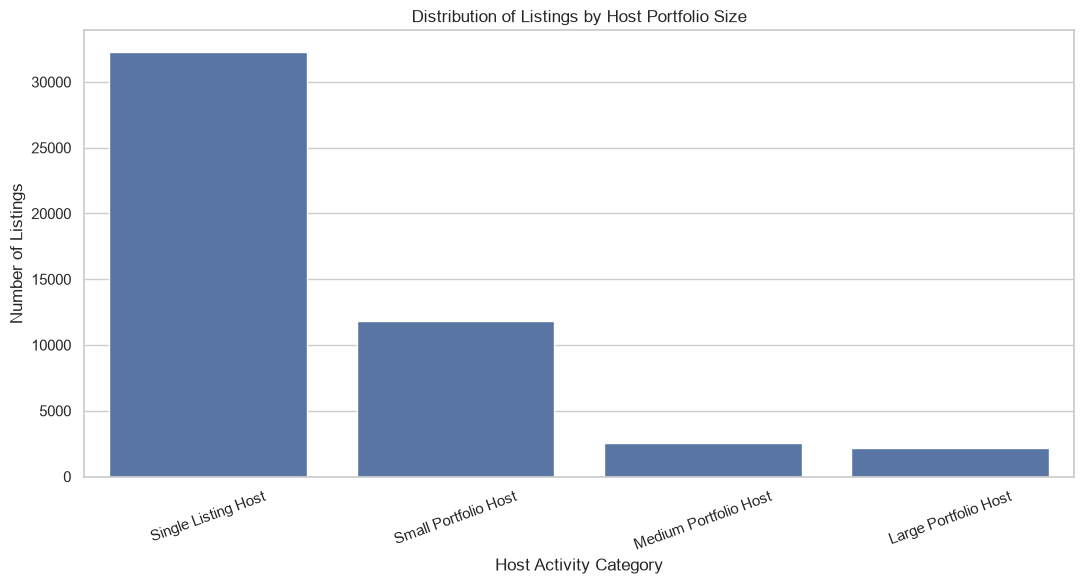

In [50]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=host_activity_summary,
    x="Host Activity",
    y="Listing Count"
)

plt.title("Distribution of Listings by Host Portfolio Size")
plt.xlabel("Host Activity Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [51]:
part2_summary = pd.DataFrame({
    "Measurement": [
        "Listings analyzed",
        "Boroughs",
        "Neighborhoods",
        "Room types",
        "Median nightly price",
        "Average nightly price",
        "Listings with reviews",
        "Listings without reviews",
        "Maximum annual availability"
    ],
    "Value": [
        len(airbnb_clean),
        airbnb_clean["neighbourhood_group"].nunique(),
        airbnb_clean["neighbourhood"].nunique(),
        airbnb_clean["room_type"].nunique(),
        round(airbnb_clean["price"].median(), 2),
        round(airbnb_clean["price"].mean(), 2),
        int(
            (
                airbnb_clean["review_status"]
                == "Reviewed"
            ).sum()
        ),
        int(
            (
                airbnb_clean["review_status"]
                == "Not Reviewed"
            ).sum()
        ),
        int(airbnb_clean["availability_365"].max())
    ]
})

part2_summary

,Measurement,Value
0,Listings analyzed,"48,884.00"
1,Boroughs,5.00
2,Neighborhoods,221.00
3,Room types,3.00
4,Median nightly price,106.00
5,Average nightly price,144.03
6,Listings with reviews,"38,833.00"
7,Listings without reviews,"10,051.00"
8,Maximum annual availability,365.00


The second phase identified strong skewness and extreme values in price, minimum nights, review activity, and host-listing counts.

Potential outliers were calculated using the IQR method. Because many extreme values may represent legitimate listings, percentile capping was applied instead of deleting all unusual observations.

Four new analytical features were created:

- Price category
- Review status
- Availability level
- Host activity category

Exploratory analysis revealed important differences across boroughs, room types, neighborhoods, availability groups, and host portfolio sizes. The results indicate that geography and room type are especially important factors for understanding nightly price.

The dataset is now ready for correlation analysis, multivariable exploration, final insights, and export in Part 3.

This section examines relationships among numerical and categorical variables, summarizes the major findings from exploratory data analysis, and saves the prepared dataset for future project deliverables.

The analysis includes:

- Correlation analysis
- Price relationships with reviews and availability
- Grouped statistical summaries
- Multivariable visualization
- Comparison of the original and cleaned datasets
- Export of the cleaned dataset
- Final modeling recommendations

In [52]:
# Select numerical attributes for correlation analysis

correlation_features = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

correlation_matrix = (
    airbnb_clean[correlation_features]
    .corr()
)

correlation_matrix.round(2)

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.00,0.08,0.06,0.04,-0.02,-0.02,0.03,-0.01
longitude,0.08,1.00,-0.26,-0.10,0.06,0.13,-0.11,0.08
price,0.06,-0.26,1.00,0.05,-0.07,-0.06,0.13,0.12
minimum_nights,0.04,-0.10,0.05,1.00,-0.15,-0.23,0.33,0.24
number_of_reviews,-0.02,0.06,-0.07,-0.15,1.00,0.62,-0.08,0.18
reviews_per_month,-0.02,0.13,-0.06,-0.23,0.62,1.00,-0.06,0.17
calculated_host_listings_count,0.03,-0.11,0.13,0.33,-0.08,-0.06,1.00,0.24
availability_365,-0.01,0.08,0.12,0.24,0.18,0.17,0.24,1.00


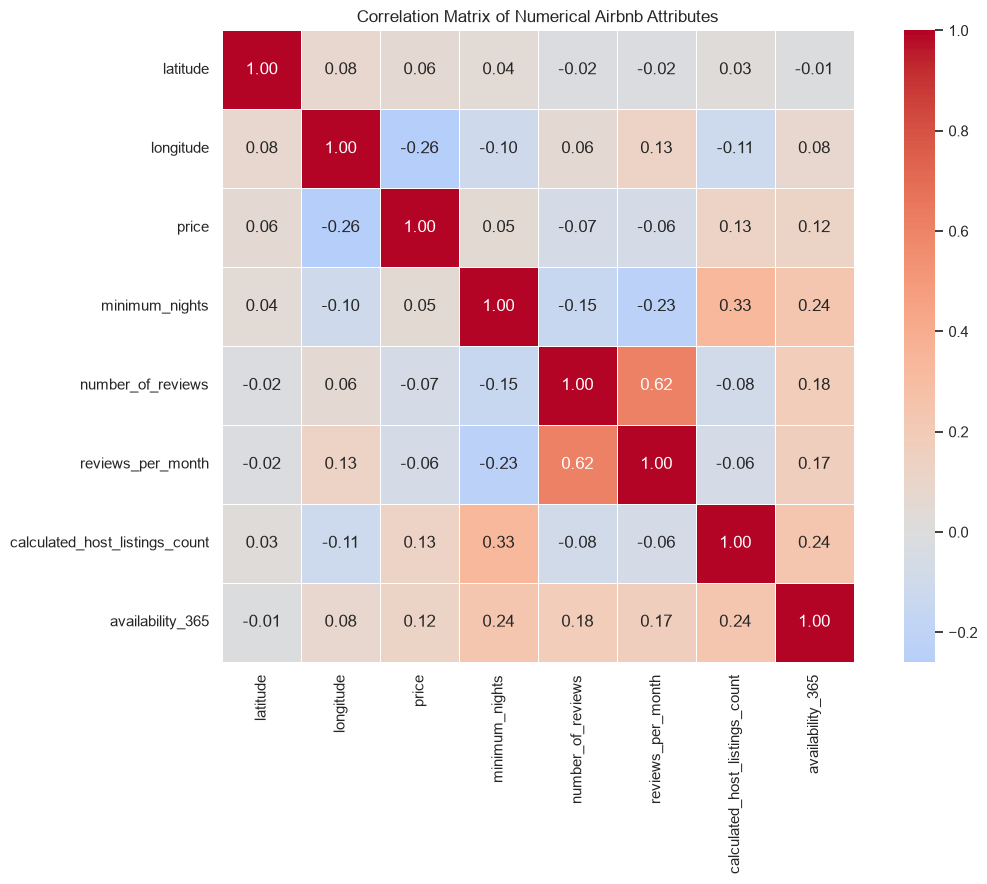

In [53]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Airbnb Attributes")

plt.tight_layout()
plt.show()

## Correlation Interpretation

The correlation heatmap measures the strength and direction of linear relationships between numerical variables.

A value close to:

- **1** indicates a strong positive linear relationship.
- **-1** indicates a strong negative linear relationship.
- **0** indicates little or no linear relationship.

Weak correlation does not mean that a variable is unimportant. Price may still have meaningful nonlinear or categorical relationships with borough, neighborhood, room type, and host behavior.

In [54]:
price_correlation_ranking = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(ascending=False)
    .rename("Correlation with Price")
    .reset_index()
    .rename(columns={"index": "Attribute"})
)

price_correlation_ranking

,Attribute,Correlation with Price
0,calculated_host_listings_count,0.13
1,availability_365,0.12
2,latitude,0.06
3,minimum_nights,0.05
4,reviews_per_month,-0.06
5,number_of_reviews,-0.07
6,longitude,-0.26


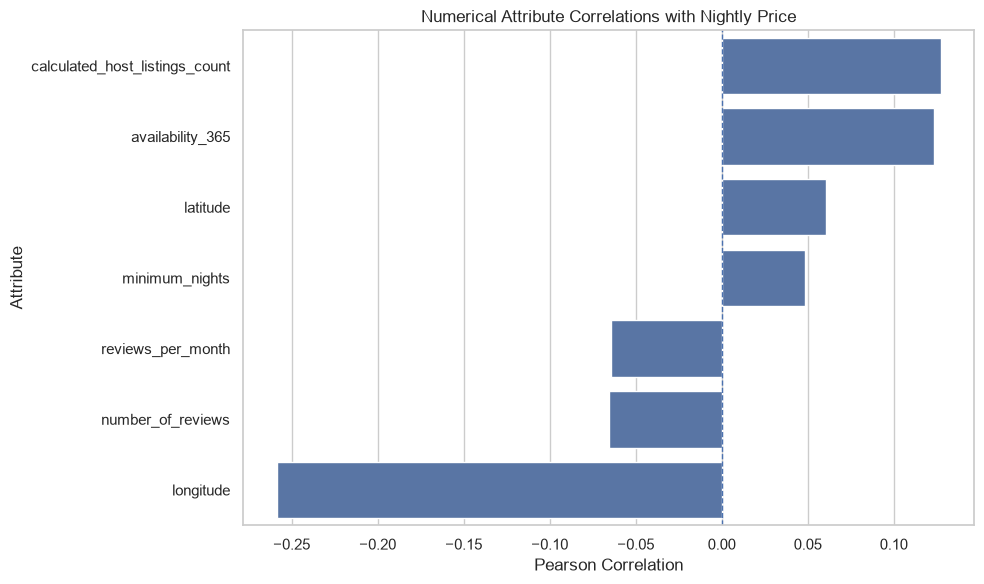

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=price_correlation_ranking,
    x="Correlation with Price",
    y="Attribute"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.title("Numerical Attribute Correlations with Nightly Price")
plt.xlabel("Pearson Correlation")
plt.ylabel("Attribute")

plt.tight_layout()
plt.show()

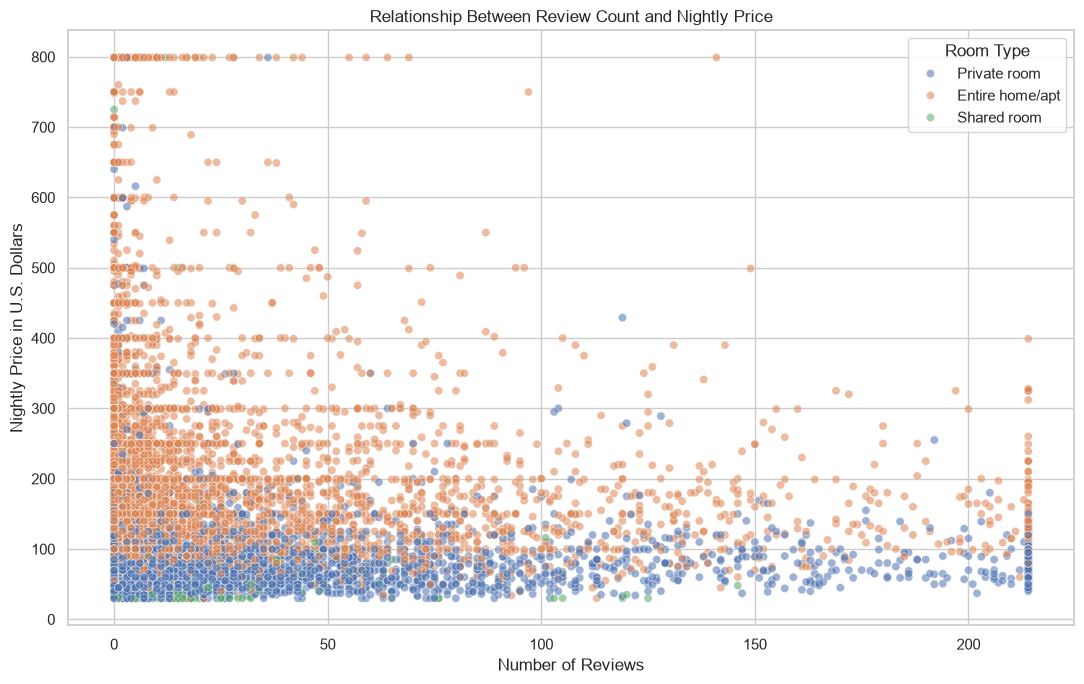

In [56]:
# Use a reproducible sample to keep the plot readable

review_price_sample = airbnb_clean.sample(
    n=min(12000, len(airbnb_clean)),
    random_state=42
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=review_price_sample,
    x="number_of_reviews",
    y="price",
    hue="room_type",
    alpha=0.55,
    s=35
)

plt.title("Relationship Between Review Count and Nightly Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Nightly Price in U.S. Dollars")
plt.legend(title="Room Type")

plt.tight_layout()
plt.show()

### Reviews and Price Insight

The scatter plot shows that listings with many reviews appear across multiple price levels. Review count alone may not strongly predict nightly price.

Room type provides additional separation, suggesting that categorical characteristics may explain pricing differences more effectively than review count by itself.

In [57]:
availability_price_summary = (
    airbnb_clean
    .groupby(
        "availability_level",
        observed=True
    )
    .agg(
        Listing_Count=("id", "count"),
        Median_Price=("price", "median"),
        Mean_Price=("price", "mean"),
        Median_Reviews=("number_of_reviews", "median")
    )
    .round(2)
    .reset_index()
)

availability_price_summary

,availability_level,Listing_Count,Median_Price,Mean_Price,Median_Reviews
0,Low,29241,100.00,132.65,4.00
1,Moderate,5282,110.00,149.39,12.00
2,High,4511,125.00,165.93,19.00
3,Very High,9850,120.00,164.93,7.00


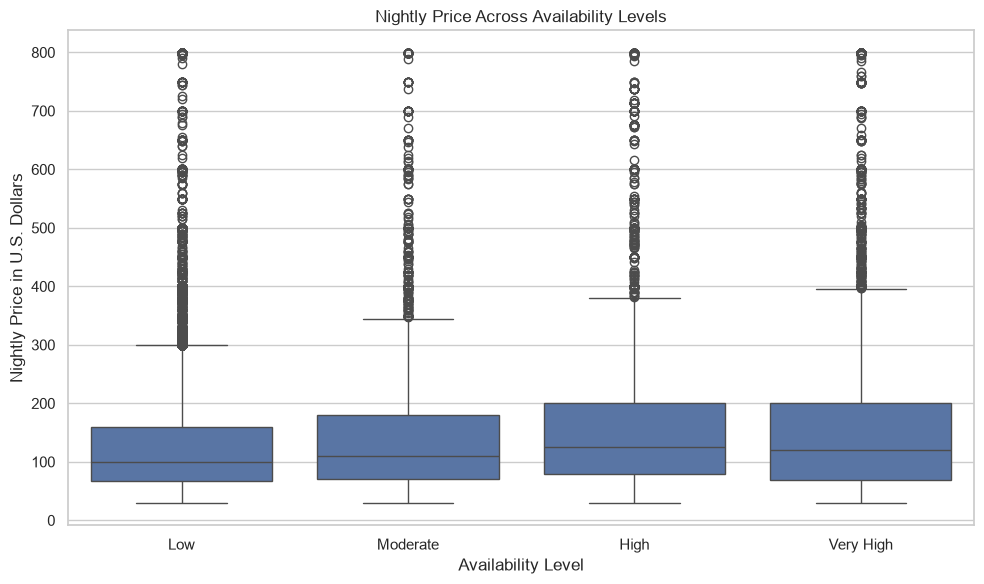

In [58]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=airbnb_clean,
    x="availability_level",
    y="price",
    order=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.title("Nightly Price Across Availability Levels")
plt.xlabel("Availability Level")
plt.ylabel("Nightly Price in U.S. Dollars")

plt.tight_layout()
plt.show()

In [59]:
host_price_summary = (
    airbnb_clean
    .groupby(
        "host_activity",
        observed=True
    )
    .agg(
        Listing_Count=("id", "count"),
        Average_Price=("price", "mean"),
        Median_Price=("price", "median"),
        Average_Availability=("availability_365", "mean"),
        Average_Reviews=("number_of_reviews", "mean")
    )
    .round(2)
    .reset_index()
)

host_price_summary

,host_activity,Listing_Count,Average_Price,Median_Price,Average_Availability,Average_Reviews
0,Single Listing Host,32301,149.38,119.00,78.90,19.99
1,Small Portfolio Host,11792,120.28,85.00,147.79,33.80
2,Medium Portfolio Host,2586,135.49,85.00,234.32,20.84
3,Large Portfolio Host,2205,202.70,189.00,279.27,3.00


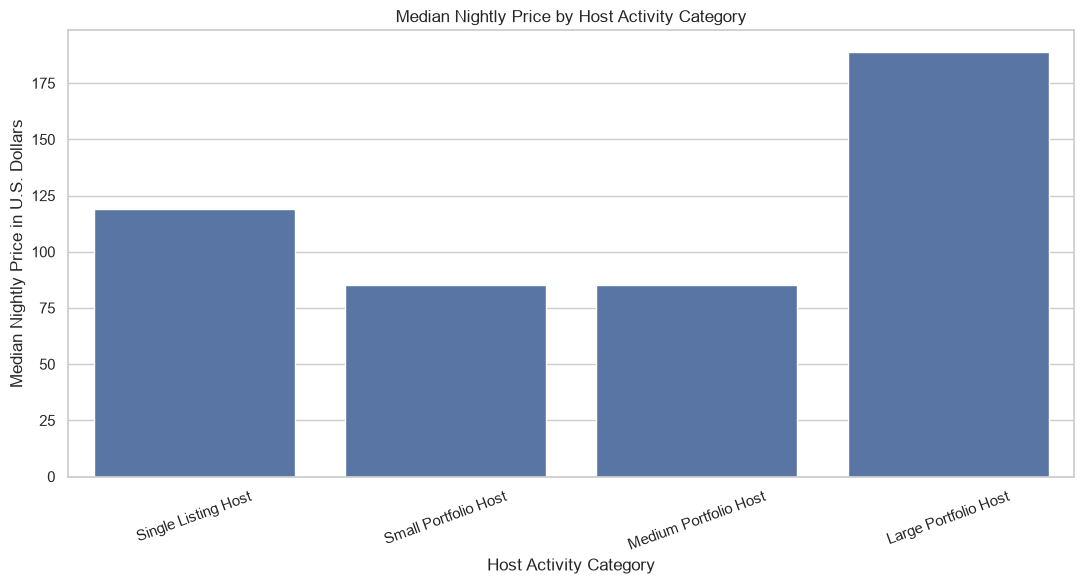

In [60]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=host_price_summary,
    x="host_activity",
    y="Median_Price"
)

plt.title("Median Nightly Price by Host Activity Category")
plt.xlabel("Host Activity Category")
plt.ylabel("Median Nightly Price in U.S. Dollars")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [61]:
borough_room_statistics = (
    airbnb_clean
    .groupby(
        [
            "neighbourhood_group",
            "room_type"
        ],
        observed=True
    )
    .agg(
        Listing_Count=("id", "count"),
        Average_Price=("price", "mean"),
        Median_Price=("price", "median"),
        Average_Minimum_Nights=("minimum_nights", "mean"),
        Average_Reviews=("number_of_reviews", "mean"),
        Average_Availability=("availability_365", "mean")
    )
    .round(2)
    .reset_index()
)

borough_room_statistics

,neighbourhood_group,room_type,Listing_Count,Average_Price,Median_Price,Average_Minimum_Nights,Average_Reviews,Average_Availability
0,Bronx,Entire home/apt,379,126.98,100.00,4.63,30.36,158.00
1,Bronx,Private room,651,64.46,54.00,3.30,24.46,171.40
2,Bronx,Shared room,60,61.68,40.00,2.62,7.20,154.22
3,Brooklyn,Entire home/apt,9558,170.59,145.00,5.65,27.36,97.21
4,Brooklyn,Private room,10126,73.96,65.00,4.92,20.57,99.91
5,Brooklyn,Shared room,411,52.06,36.00,7.51,14.02,177.73
6,Manhattan,Entire home/apt,13198,229.89,191.00,9.13,17.53,117.15
7,Manhattan,Private room,7982,111.08,90.00,4.69,25.11,101.85
8,Manhattan,Shared room,480,88.70,69.00,4.02,21.32,138.57
9,Queens,Entire home/apt,2096,143.68,120.00,4.57,28.14,132.27


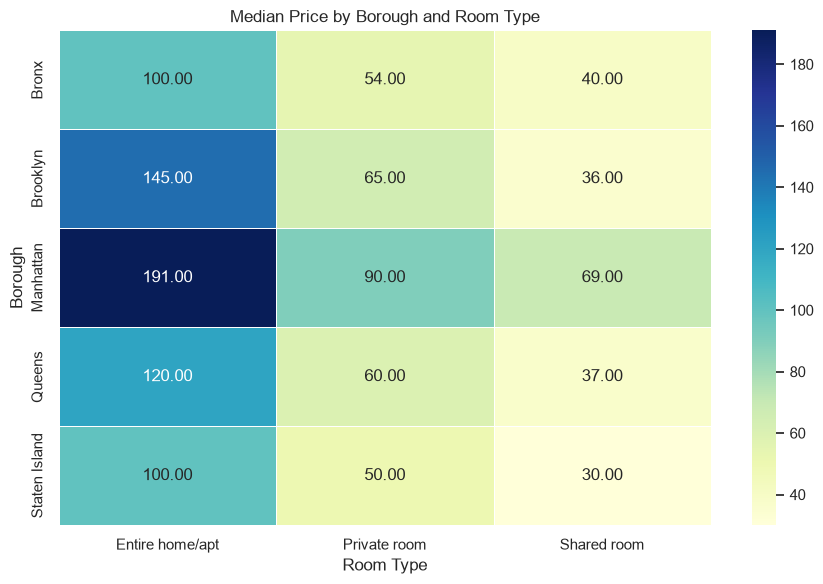

In [62]:
price_pivot = borough_room_statistics.pivot(
    index="neighbourhood_group",
    columns="room_type",
    values="Median_Price"
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    price_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Median Price by Borough and Room Type")
plt.xlabel("Room Type")
plt.ylabel("Borough")

plt.tight_layout()
plt.show()

### Borough and Room-Type Insight

The grouped statistics and heatmap show that nightly price differs across both borough and room type.

The interaction between these two variables is important. For example, an entire home in one borough may have a very different typical price from a private room in another borough.

Future regression models should therefore include both borough and room type and may also evaluate interaction effects.

In [63]:
neighborhood_price_summary = (
    airbnb_clean
    .groupby("neighbourhood")
    .agg(
        Listing_Count=("id", "count"),
        Median_Price=("price", "median"),
        Average_Price=("price", "mean"),
        Average_Reviews=("number_of_reviews", "mean")
    )
    .query("Listing_Count >= 100")
    .sort_values(
        "Median_Price",
        ascending=False
    )
    .head(15)
    .round(2)
    .reset_index()
)

neighborhood_price_summary

,neighbourhood,Listing_Count,Median_Price,Average_Price,Average_Reviews
0,Tribeca,177,295.00,355.37,10.18
1,Midtown,1545,210.00,270.52,12.52
2,Financial District,744,200.00,220.47,9.22
3,West Village,768,200.00,247.32,19.20
4,SoHo,358,199.00,263.32,20.17
5,Chelsea,1113,199.00,228.03,20.90
6,Greenwich Village,392,197.50,225.75,16.65
7,Murray Hill,484,190.00,217.53,9.12
8,Theater District,288,190.00,232.50,14.57
9,Nolita,253,179.00,203.32,22.09


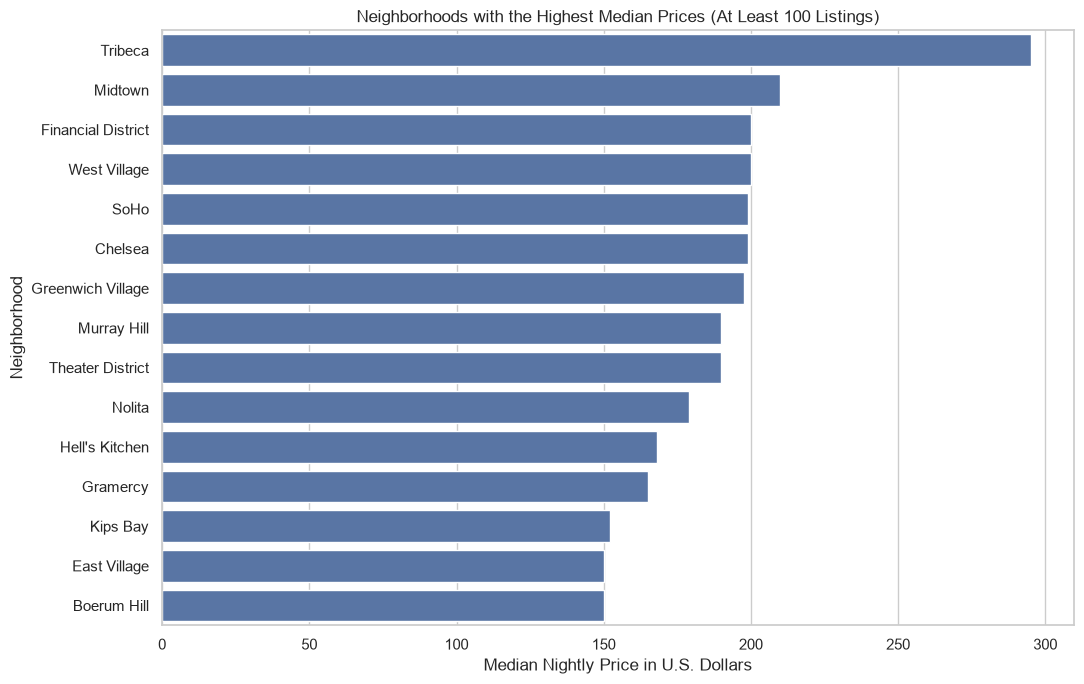

In [64]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=neighborhood_price_summary,
    x="Median_Price",
    y="neighbourhood"
)

plt.title(
    "Neighborhoods with the Highest Median Prices "
    "(At Least 100 Listings)"
)

plt.xlabel("Median Nightly Price in U.S. Dollars")
plt.ylabel("Neighborhood")

plt.tight_layout()
plt.show()

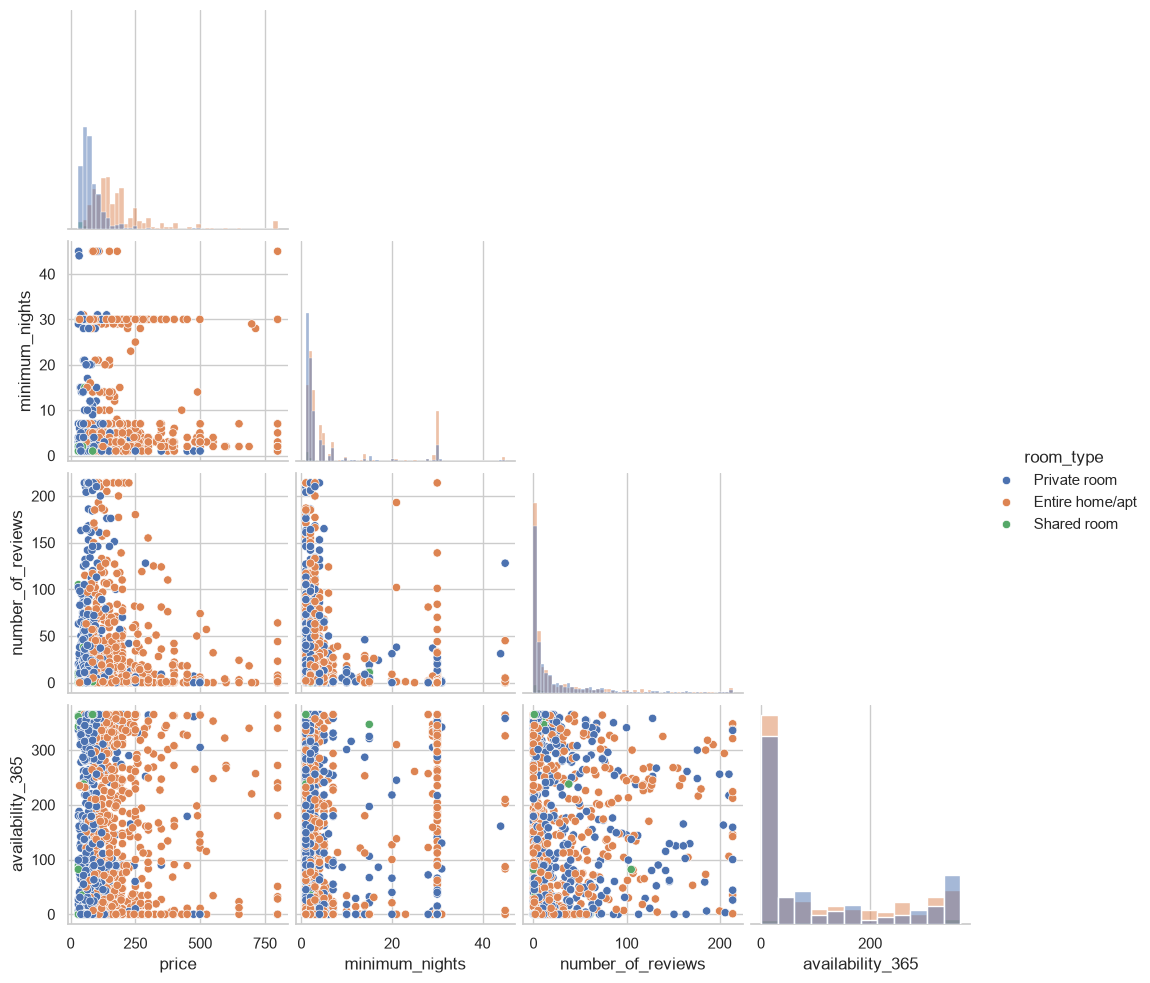

In [65]:
pairplot_features = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "room_type"
]

pairplot_sample = airbnb_clean[
    pairplot_features
].sample(
    n=min(1500, len(airbnb_clean)),
    random_state=42
)

sns.pairplot(
    pairplot_sample,
    hue="room_type",
    corner=True,
    diag_kind="hist"
)

plt.show()

### Multivariable Exploration Insight

The pair plot compares price, minimum nights, review count, and availability while separating listings by room type.

The distributions show that:

- Numerical variables remain skewed even after extreme-value treatment.
- Room types occupy different price ranges.
- Review activity varies widely within each accommodation category.
- Availability does not have a simple linear relationship with price.
- Future models may benefit from scaling, transformation, and categorical encoding.

In [66]:
original_cleaned_comparison = pd.DataFrame({
    "Measurement": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Exact duplicate rows",
        "Zero or negative prices",
        "Maximum price",
        "Maximum minimum nights",
        "Maximum review count"
    ],
    "Original Dataset": [
        airbnb_raw.shape[0],
        airbnb_raw.shape[1],
        int(airbnb_raw.isna().sum().sum()),
        int(airbnb_raw.duplicated().sum()),
        int((airbnb_raw["price"] <= 0).sum()),
        airbnb_raw["price"].max(),
        airbnb_raw["minimum_nights"].max(),
        airbnb_raw["number_of_reviews"].max()
    ],
    "Cleaned Dataset": [
        airbnb_clean.shape[0],
        airbnb_clean.shape[1],
        int(airbnb_clean.isna().sum().sum()),
        int(airbnb_clean.duplicated().sum()),
        int((airbnb_clean["price"] <= 0).sum()),
        airbnb_clean["price"].max(),
        airbnb_clean["minimum_nights"].max(),
        airbnb_clean["number_of_reviews"].max()
    ]
})

original_cleaned_comparison

,Measurement,Original Dataset,Cleaned Dataset
0,Number of rows,48895,48884
1,Number of columns,16,20
2,Total missing values,20141,10051
3,Exact duplicate rows,0,0
4,Zero or negative prices,11,0
5,Maximum price,10000,799
6,Maximum minimum nights,1250,45
7,Maximum review count,629,214


In [67]:
final_quality_check = pd.DataFrame({
    "Check": [
        "Exact duplicates",
        "Duplicate listing IDs",
        "Invalid prices",
        "Invalid minimum nights",
        "Negative review counts",
        "Invalid availability values",
        "Invalid latitude values",
        "Invalid longitude values"
    ],
    "Remaining Count": [
        int(airbnb_clean.duplicated().sum()),
        int(airbnb_clean["id"].duplicated().sum()),
        int((airbnb_clean["price"] <= 0).sum()),
        int((airbnb_clean["minimum_nights"] < 1).sum()),
        int((airbnb_clean["number_of_reviews"] < 0).sum()),
        int(
            (
                ~airbnb_clean["availability_365"]
                .between(0, 365)
            ).sum()
        ),
        int(
            (
                ~airbnb_clean["latitude"]
                .between(-90, 90)
            ).sum()
        ),
        int(
            (
                ~airbnb_clean["longitude"]
                .between(-180, 180)
            ).sum()
        )
    ]
})

final_quality_check

,Check,Remaining Count
0,Exact duplicates,0
1,Duplicate listing IDs,0
2,Invalid prices,0
3,Invalid minimum nights,0
4,Negative review counts,0
5,Invalid availability values,0
6,Invalid latitude values,0
7,Invalid longitude values,0


In [68]:
output_filename = "cleaned_nyc_airbnb.csv"

airbnb_clean.to_csv(
    output_filename,
    index=False
)

print("Cleaned dataset exported successfully.")
print("Output file:", output_filename)
print("Final number of rows:", airbnb_clean.shape[0])
print("Final number of columns:", airbnb_clean.shape[1])

Cleaned dataset exported successfully.
Output file: cleaned_nyc_airbnb.csv
Final number of rows: 48884
Final number of columns: 20


In [69]:
# Reload the exported file to confirm that it was saved correctly

exported_data_check = pd.read_csv(
    "cleaned_nyc_airbnb.csv"
)

print("Export verification successful.")
print("Reloaded rows:", exported_data_check.shape[0])
print("Reloaded columns:", exported_data_check.shape[1])

exported_data_check.head()

Export verification successful.
Reloaded rows: 48884
Reloaded columns: 20


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category,review_status,availability_level,host_activity
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365,Moderate,Reviewed,Very High,Medium Portfolio Host
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,Premium,Reviewed,Very High,Small Portfolio Host
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,0.00,1,365,Moderate,Not Reviewed,Very High,Single Listing Host
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,214,2019-07-05,4.64,1,194,Budget,Reviewed,High,Single Listing Host
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,Budget,Reviewed,Low,Single Listing Host


In [70]:
final_project_summary = pd.DataFrame({
    "Project Measure": [
        "Original records",
        "Cleaned records",
        "Original attributes",
        "Final attributes",
        "Borough groups",
        "Neighborhoods",
        "Room types",
        "Median cleaned price",
        "Average cleaned price",
        "Listings with reviews",
        "Listings without reviews",
        "Remaining invalid records"
    ],
    "Result": [
        airbnb_raw.shape[0],
        airbnb_clean.shape[0],
        airbnb_raw.shape[1],
        airbnb_clean.shape[1],
        airbnb_clean["neighbourhood_group"].nunique(),
        airbnb_clean["neighbourhood"].nunique(),
        airbnb_clean["room_type"].nunique(),
        round(airbnb_clean["price"].median(), 2),
        round(airbnb_clean["price"].mean(), 2),
        int(
            (
                airbnb_clean["review_status"]
                == "Reviewed"
            ).sum()
        ),
        int(
            (
                airbnb_clean["review_status"]
                == "Not Reviewed"
            ).sum()
        ),
        int(final_quality_check["Remaining Count"].sum())
    ]
})

final_project_summary

,Project Measure,Result
0,Original records,"48,895.00"
1,Cleaned records,"48,884.00"
2,Original attributes,16.00
3,Final attributes,20.00
4,Borough groups,5.00
5,Neighborhoods,221.00
6,Room types,3.00
7,Median cleaned price,106.00
8,Average cleaned price,144.03
9,Listings with reviews,"38,833.00"


# Key Insights from Exploratory Data Analysis

## 1. Listing distribution is geographically concentrated

Airbnb listings are not evenly distributed across New York City. A substantial portion of the inventory is concentrated in a smaller number of boroughs and neighborhoods.

This indicates that location should be included in future predictive and clustering models.

## 2. Room type is strongly connected with price

Entire homes or apartments, private rooms, and shared rooms follow noticeably different price distributions.

Room type is therefore expected to be one of the most useful categorical predictors of nightly price.

## 3. Price is strongly right-skewed

The original nightly-price distribution contained a long right tail and unusually high values. Percentile capping reduced the influence of extreme observations while retaining the listings.

A logarithmic transformation of price may still be useful during regression modeling.

## 4. Review activity alone does not explain price

Listings with both high and low review counts appear across multiple price ranges. This suggests that review count alone is not sufficient to predict nightly price.

Review activity may become more useful when combined with room type, location, and availability.

## 5. Availability patterns vary substantially

Listings differ greatly in the number of days they are available during the year. Availability may reflect host strategy, demand, occupancy, or whether a listing is used as a full-time rental.

## 6. Professional and individual hosts show different patterns

The engineered host-activity categories reveal differences between single-listing hosts and hosts managing larger portfolios.

Host activity may help identify business-oriented listings and may contribute to clustering or classification.

## 7. Linear correlation is limited

Several numerical variables have weak Pearson correlations with price. However, borough, neighborhood, and room type show meaningful differences through grouped analysis and visualizations.

Future models should include categorical encoding and should not rely only on linear correlation.

## 8. Missing review dates have business meaning

Missing `last_review` values were preserved because they may indicate listings that have never received a review rather than incorrect data.

The engineered review-status field provides a clearer feature for future analysis.

## 9. Feature engineering improved analytical value

The following features were created:

- `price_category`
- `review_status`
- `availability_level`
- `host_activity`

These variables provide interpretable categories for later classification, clustering, and association-rule mining.

## 10. Dataset readiness

The cleaned dataset is suitable for future project stages involving:

- Regression using nightly price as the target
- Classification using price category or review status
- Clustering of listing profiles
- Association-rule mining using discretized listing characteristics

# Recommendations for Future Modeling

## Regression

Nightly price can serve as the target variable.

Recommended predictors include:

- Borough
- Neighborhood
- Room type
- Latitude and longitude
- Minimum nights
- Review activity
- Availability
- Host listing count

Recommended preparation steps include one-hot encoding categorical variables, scaling numerical features when required, and evaluating a log transformation of price.

## Classification

The engineered `price_category` feature can be used as a classification target.

Because the category distribution may be imbalanced, future evaluation should include precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

## Clustering

Clustering can be performed using standardized values such as:

- Price
- Minimum nights
- Number of reviews
- Reviews per month
- Availability
- Host listing count
- Latitude
- Longitude

Cluster interpretation can identify budget listings, highly available professional listings, popular properties, and location-based segments.

## Association Rule Mining

Association-rule analysis can use categorical and discretized attributes such as:

- Borough
- Room type
- Price category
- Review status
- Availability level
- Host activity category

These combinations may reveal common listing profiles and market patterns.

# Conclusion

Project Deliverable 1 successfully completed the data collection, cleaning, and exploratory analysis stages of the data-mining process.

The New York City Airbnb 2019 dataset was selected because it contains 48,895 records and 16 original attributes, including numerical, categorical, text, date, and geographic information.

The dataset was validated before analysis. Missing listing and host names were replaced with meaningful labels, missing monthly-review values were replaced with zero, and missing review dates were preserved when they represented listings without recorded review history.

Duplicate records, repeated listing identifiers, inconsistent text spacing, invalid prices, impossible numerical values, and extreme observations were examined. Invalid records were removed, while extreme but potentially legitimate values were controlled through percentile capping.

Feature engineering produced price categories, review-status labels, availability groups, and host-activity categories. Exploratory visualizations examined listing supply, price variation, room types, boroughs, neighborhoods, geographic clustering, review activity, availability, host behavior, and numerical relationships.

The analysis showed that location and room type are especially important for explaining price variation. Numerical correlations with price were generally limited, indicating that future models should include categorical encoding, nonlinear relationships, and interaction effects.

The cleaned dataset was exported as `cleaned_nyc_airbnb.csv` and verified successfully. It is now ready for regression, classification, clustering, and association-rule mining in later project deliverables.